# Eksploracyjna Analiza Danych - Szkoły i Placówki Oświatowe w Polsce w roku 2025/2026

## 1. Wstęp
Poniższy projekt ma na celu przeprowadzenie opisowej analizy wybranego zbioru danych z wykorzystaniem metod statystyki opisowej oraz odpowiednich narzędzi wizualizacyjnych. Analiza ta pozwoli na lepsze zrozumienie struktury danych, identyfikację zależności pomiędzy zmiennymi oraz wykrycie ewentualnych nieprawidłowości lub anomalii.

Jako temat analizy został wybrany **zbiór danych dotyczący szkół i placówek oświatowych w Polsce.** Dane te obejmują szeroki zakres informacji o jednostkach edukacyjnych. Wybór ten wynika z praktycznego znaczenia tych informacji. Dane o systemie oświaty są istotne zarówno z punktu widzenia administracji publicznej, jak i analiz społecznych. Dodatkowo duża liczba obserwacji oraz kolumn umożliwia zastosowanie różnych metod analizy oraz wizualizacji.

## 2. Opis zbioru danych
### Nazwa zbioru danych
Wykaz szkół i placówek oświatowych wg stanu bazy SIO na 30.09.2025

### Źródło danych
Analizowany zbiór danych pochodzi z portalu [dane.gov.pl](dane.gov.pl) i dotyczy wykazu szkół i placówek oświatowych w Polsce Dane pochodzą z Rejestru Szkół i Placówek Oświatowych (RSPO), który jest częścią Systemu Informacji Oświatowej (SIO). Rejestr zawiera informacje o wszystkich działających oraz zlikwidowanych szkołach i placówkach oświatowych w Polsce.

Poziom otwartości danych oceniono na ★★★★☆ (4/5), co oznacza wysoki stopień dostępności i przejrzystości danych publicznych. Dane zostały udostępnione 16 lutego 2026 r., a stan zbioru odpowiada danym dla 25 listopada 2025 r., co potwierdza jednolitość roku szkolnego (2025/2026) w analizowanym zbiorze, aczkolweik jest niespójne z wspomnianym w tytule terminem 30 września 2025 r.

**LINK:** [Wykaz szkół i placówek oświatowych](https://dane.gov.pl/pl/dataset/839,wykaz-szko-i-placowek-oswiatowych)



### Charakterystyka danych
Zbiór składa się z **ponad 50 tysięcy rekordów i 58 cech** - zawiera szczegółowe informacje o szkołach i placówkach edukacyjnych w Polsce, zarówno publicznych, jak i niepublicznych. Dane mają charakter tabularyczny i obejmują m.in.:

- **Zmienne jakościowe:**
    - nazwę placówki,
    - typ szkoły lub placówki (np. szkoła podstawowa, liceum, technikum),
    - dane adresowe i lokalizacyjne (województwo, powiat, gmina),
    - informacje o organie prowadzącym (np. gmina, fundacja),
    - status publiczno-prawny,
    - etap edukacji oraz specyfikę placówki
 

- **Zmienne numeryczne:**
    - liczba uczniów w placówce,
    - liczba dziewcząt w placówce,
    - liczba oddziałów w placówce.

Zbiór umożliwia analizę struktury systemu edukacji w Polsce, rozmieszczenia placówek, a także porównywanie szkół według różnych kryteriów (np. lokalizacji, typu czy organu prowadzącego). Dane mogą być wykorzystywane do analiz statystycznych, wizualizacji oraz badań nad systemem oświaty.

### Załadowanie bibliotek

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 3. Przygotowanie danych (Preprocessing)

In [2]:
df = pd.read_excel('wykaz_szkol.xlsx')

### Przegląd danych

In [3]:
df.head()

,Rok szkolny,idTerytWojewodztwo,Wojewodztwo,idTerytPowiat,Powiat,idTerytGmina,Gmina,Typ gminy,Miejscowość,Czy szkoła,...,Organ rejestrujący,ucz_ogolem,w tym_ucz_dziewczeta,w tym_w oddz_przedszk,lb_oddz,etatUmowa,w tym_etat_niepełnozatr,lb_naucz_osoby,w tym_lb_naucz_pelnozatr,w tym_lb_naucz_niepelnozatr
0,2025/2026,2,DOLNOŚLĄSKIE,201,bolesławiecki,201011,Bolesławiec,M,Bolesławiec,0,...,POWIAT BOLESŁAWIECKI,NaN,NaN,NaN,NaN,45.36,6.36,52.0,39.0,13.0
1,2025/2026,2,DOLNOŚLĄSKIE,201,bolesławiecki,201011,Bolesławiec,M,Bolesławiec,1,...,POWIAT BOLESŁAWIECKI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025/2026,2,DOLNOŚLĄSKIE,201,bolesławiecki,201011,Bolesławiec,M,Bolesławiec,1,...,POWIAT BOLESŁAWIECKI,458.0,351.0,NaN,17.0,NaN,NaN,NaN,NaN,NaN
3,2025/2026,2,DOLNOŚLĄSKIE,201,bolesławiecki,201011,Bolesławiec,M,Bolesławiec,0,...,POWIAT BOLESŁAWIECKI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025/2026,2,DOLNOŚLĄSKIE,201,bolesławiecki,201011,Bolesławiec,M,Bolesławiec,1,...,POWIAT BOLESŁAWIECKI,59.0,43.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN


#### Wypisanie dostępnych kolumn

In [4]:
df.columns

Index(['Rok szkolny', 'idTerytWojewodztwo', 'Wojewodztwo', 'idTerytPowiat',
       'Powiat', 'idTerytGmina', 'Gmina', 'Typ gminy', 'Miejscowość',
       'Czy szkoła', 'idPodmiotGlowny', 'idPodmiotNadrzedny',
       'idTypPodmiotuNadrzednego', 'Typ podmiotu nadrzędnego', 'RSPO',
       'idTypPodmiotu', 'Typ podmiotu', 'idRodzajPlacowki',
       'Rodzaj szkoły/placówki', 'Nazwa placówki', 'Ulica', 'Numer domu',
       'Numer lokalu', 'Kod pocztowy', 'Poczta', 'Adres www', 'regon',
       'idPublicznosc', 'Publiczność', 'idKategoriaUczniow',
       'Kategoria uczniów', 'idSpecyfikaSzkoly', 'Specyfika szkoły',
       'idZwiazanieOrganizacyjneSzkoly', 'Związanie organizacyjne',
       'idTypOrgProw', 'Typ organu prowadzącego', 'typ_org_prow',
       'idOrganProwadzacy', 'Organ prowadzący', 'idTerytWojewOrgRej',
       'Organ rejestrującey - województwo', 'idTerytPowiatOrgRej',
       'Organ rejestrujący - powiat', 'idTerytGminaOrgRej',
       'Organ rejestrujący - gmina', 'idTypOrgRej',
   

#### Rozmiar zbioru

In [5]:
df.shape

(55741, 58)

Zbiór danych składa się z 55 741 obserwacji oraz 58 zmiennych, co wskazuje na jego dużą szczegółowość i rozbudowaną strukturę. Każdy rekord odpowiada pojedynczej jednostce (szkole lub placówce oświatowej), jednak ze względu na sposób organizacji danych część informacji jest powielona - zmienne kategoryczne mają swój odpowiednik w postaci kolumn id.

In [6]:
df_clean = df.copy()
cols_to_drop = [col for col in df_clean.columns if col.startswith('id')]
df_clean = df_clean.drop(columns=cols_to_drop)

print("Pozostałe kolumny:", df_clean.columns)
print("Liczba kolumn:", len(df_clean.columns))

Pozostałe kolumny: Index(['Rok szkolny', 'Wojewodztwo', 'Powiat', 'Gmina', 'Typ gminy',
       'Miejscowość', 'Czy szkoła', 'Typ podmiotu nadrzędnego', 'RSPO',
       'Typ podmiotu', 'Rodzaj szkoły/placówki', 'Nazwa placówki', 'Ulica',
       'Numer domu', 'Numer lokalu', 'Kod pocztowy', 'Poczta', 'Adres www',
       'regon', 'Publiczność', 'Kategoria uczniów', 'Specyfika szkoły',
       'Związanie organizacyjne', 'Typ organu prowadzącego', 'typ_org_prow',
       'Organ prowadzący', 'Organ rejestrującey - województwo',
       'Organ rejestrujący - powiat', 'Organ rejestrujący - gmina',
       'Typ organu rejestrującego', 'Organ rejestrujący', 'ucz_ogolem',
       'w tym_ucz_dziewczeta', 'w tym_w oddz_przedszk', 'lb_oddz', 'etatUmowa',
       'w tym_etat_niepełnozatr', 'lb_naucz_osoby', 'w tym_lb_naucz_pelnozatr',
       'w tym_lb_naucz_niepelnozatr'],
      dtype='object')
Liczba kolumn: 40


### Standaryzacja nazw kolumn

In [7]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(r'([a-z0-9])([A-Z])', r'\1_\2', regex=True)
    .str.lower()
    .str.replace("ą", "a").str.replace("ę", "e").str.replace("ć", "c")
    .str.replace("ł", "l").str.replace("ń", "n").str.replace("ó", "o")
    .str.replace("ś", "s").str.replace("ż", "z").str.replace("ź", "z")
    .str.replace(r"[^\w\s]", "_", regex=True)
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

df_clean.columns

Index(['rok_szkolny', 'wojewodztwo', 'powiat', 'gmina', 'typ_gminy',
       'miejscowosc', 'czy_szkola', 'typ_podmiotu_nadrzednego', 'rspo',
       'typ_podmiotu', 'rodzaj_szkoly_placowki', 'nazwa_placowki', 'ulica',
       'numer_domu', 'numer_lokalu', 'kod_pocztowy', 'poczta', 'adres_www',
       'regon', 'publicznosc', 'kategoria_uczniow', 'specyfika_szkoly',
       'zwiazanie_organizacyjne', 'typ_organu_prowadzacego', 'typ_org_prow',
       'organ_prowadzacy', 'organ_rejestrujacey_wojewodztwo',
       'organ_rejestrujacy_powiat', 'organ_rejestrujacy_gmina',
       'typ_organu_rejestrujacego', 'organ_rejestrujacy', 'ucz_ogolem',
       'w_tym_ucz_dziewczeta', 'w_tym_w_oddz_przedszk', 'lb_oddz',
       'etat_umowa', 'w_tym_etat_niepelnozatr', 'lb_naucz_osoby',
       'w_tym_lb_naucz_pelnozatr', 'w_tym_lb_naucz_niepelnozatr'],
      dtype='object')

In [8]:
df_clean.shape

(55741, 40)

Liczba zmiennych w zbiorze zmniejszyła się znacząco - dalej jest to jednka wysoka wartość odpowiednia do analizy.

#### Usunięte kolumny
W ramach przygotowania zbioru danych do analizy statystycznej podjęto decyzję o usunięciu zmiennych identyfikujących (kolumn id). Zmienne te pełnią funkcję kluczy w bazach danych lub mogłyby służyć jako zdekodowane zmienne kategoryczny do algorytmów, ale nie posiadają wartości merytorycznej dla obliczeń statystycznych.

In [9]:
df_clean['rok_szkolny'].unique()

array(['2025/2026'], dtype=object)

In [10]:
df_clean.drop('rok_szkolny', axis=1, inplace=True)

Analizowany zbiór obejmuje dane dla jednego roku szkolnego. Zarówno metadane, jak i analiza zawartości kolumny „Rok szkolny” wskazują, że wszystkie rekordy dotyczą roku szkolnego 2025/2026. Potwierdza to fakt, że kolumna ta przyjmuje wyłącznie jedną unikalną wartość, co oznacza brak zróżnicowania czasowego w analizowanym zbiorze. Kolumna ta zostałą usunięta.

## Wartości brakujące - procent dla danej kolumny

In [11]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
display(missing_percentage.sort_values(ascending=False))

numer_lokalu                       95.174109
typ_podmiotu_nadrzednego           70.474157
w_tym_w_oddz_przedszk              60.883371
w_tym_lb_naucz_niepelnozatr        46.579717
w_tym_lb_naucz_pelnozatr           46.579717
lb_naucz_osoby                     46.579717
w_tym_etat_niepelnozatr            46.579717
etat_umowa                         46.579717
w_tym_ucz_dziewczeta               31.127895
lb_oddz                            30.090956
ucz_ogolem                         30.090956
adres_www                          25.137690
organ_rejestrujacy_gmina           25.031844
zwiazanie_organizacyjne            24.109722
ulica                              16.303977
organ_rejestrujacy_powiat           4.144167
organ_rejestrujacey_wojewodztwo     2.299923
typ_organu_rejestrujacego           0.000000
organ_rejestrujacy                  0.000000
typ_organu_prowadzacego             0.000000
organ_prowadzacy                    0.000000
typ_org_prow                        0.000000
wojewodztw

In [12]:
df_clean = df_clean.drop(columns=[
    'numer_lokalu',
    'typ_podmiotu_nadrzednego'
])

#### Ponowne sprawdzenie po usunięciu dwóch kolumn

In [13]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
display(missing_percentage.sort_values(ascending=False))

w_tym_w_oddz_przedszk              60.883371
w_tym_lb_naucz_niepelnozatr        46.579717
w_tym_lb_naucz_pelnozatr           46.579717
lb_naucz_osoby                     46.579717
w_tym_etat_niepelnozatr            46.579717
etat_umowa                         46.579717
w_tym_ucz_dziewczeta               31.127895
lb_oddz                            30.090956
ucz_ogolem                         30.090956
adres_www                          25.137690
organ_rejestrujacy_gmina           25.031844
zwiazanie_organizacyjne            24.109722
ulica                              16.303977
organ_rejestrujacy_powiat           4.144167
organ_rejestrujacey_wojewodztwo     2.299923
typ_organu_rejestrujacego           0.000000
organ_rejestrujacy                  0.000000
typ_organu_prowadzacego             0.000000
organ_prowadzacy                    0.000000
typ_org_prow                        0.000000
wojewodztwo                         0.000000
powiat                              0.000000
kategoria_

#### Wnioski
Po wyświetleniu procentowego udziału brakujących danych stwierdzono, że w zbiorze występują one w znacznym i zróżnicowanym zakresie. **Największe braki dotyczą zmiennych o charakterze techniczno-adresowym**, takich jak „Numer lokalu” oraz „Typ podmiotu nadrzędnego”, które zostały **usunięte z dalszej analizy** ze względu na bardzo wysoki poziom braków oraz ograniczoną wartość analityczną.

Istotne braki występują również w zmiennych liczbowych, w szczególności dotyczących zatrudnienia nauczycieli (ok. 46%) oraz liczby uczniów i oddziałów (ok. 30%). Mimo wysokiego poziomu braków zmienne te zostały zachowane, ponieważ stanowią jedne z kluczowych informacji opisujących funkcjonowanie jednostek oświatowych i są istotne z punktu widzenia analizy struktury systemu edukacji.

Przeanalizowano również możliwość usunięcia obserwacji zawierających brakujące wartości. Ze względu na znaczny rozmiar zbioru danych (55 741 obserwacji) oraz wysoki i nierównomierny poziom braków w poszczególnych zmiennych, podejście to zostało odrzucone. Braki w danych nie są równomierne i dotyczą głównie wybranych grup zmiennych, co może sugerować ich częściowo systematyczny charakter **(np. różnice w raportowaniu danych przez poszczególne jednostki oświatowe)**. Z tego względu **zrezygnowano z imputacji braków**, aby nie zaburzać rzeczywistego obrazu danych.

Dodatkowo analiza zbioru wskazuje, że dane pochodzące z rzeczywistych rejestrów administracyjnych mogą być istotnie niekompletne. Jest to naturalna cecha danych rzeczywistych, w przeciwieństwie do danych syntetycznych (często używanych w projektach osobistych, studenckich), które są zazwyczaj kompletne i uporządkowane. W tym przypadku obecność braków stanowi więc odzwierciedlenie realnych ograniczeń procesów gromadzenia i raportowania danych w systemie oświaty.

In [14]:
df_clean.describe()

,czy_szkola,rspo,regon,ucz_ogolem,w_tym_ucz_dziewczeta,w_tym_w_oddz_przedszk,lb_oddz,etat_umowa,w_tym_etat_niepelnozatr,lb_naucz_osoby,w_tym_lb_naucz_pelnozatr,w_tym_lb_naucz_niepelnozatr
count,55741.000000,55741.000000,5.574100e+04,38968.000000,38390.000000,21804.000000,38968.000000,29777.000000,29777.000000,29777.000000,29777.000000,29777.000000
mean,0.758562,113063.700777,1.409409e+11,173.268400,86.878145,62.388736,9.120227,24.386710,3.497735,28.420358,20.863284,7.557074
std,0.427959,121018.691965,2.838639e+12,206.750761,112.820739,54.112399,8.317477,23.643584,4.216954,25.275281,21.801177,8.347337
min,0.000000,2874.000000,1.999100e+04,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,28146.000000,6.051780e+07,47.000000,22.000000,22.000000,3.000000,8.320000,0.940000,11.000000,6.000000,3.000000
50%,1.000000,75044.000000,2.607885e+08,103.000000,50.000000,45.000000,7.000000,16.810000,2.370000,21.000000,14.000000,6.000000
75%,1.000000,126917.000000,3.836574e+08,212.000000,104.000000,91.000000,11.000000,33.990000,4.660000,39.000000,29.000000,10.000000
max,1.000000,484847.000000,9.707781e+13,8978.000000,5506.000000,632.000000,127.000000,316.450000,101.710000,442.000000,309.000000,287.000000


### Wartości nietypowe i podejrzane (outliery) - usuwanie wartości odstających (IQR)

W celu identyfikacji wartości nietypowych przeprowadzono analizę zmiennych liczbowych z wykorzystaniem histogramów oraz wykresów pudełkowych (boxplot), a jako pierwszy krok przyjrzano się wynikowi funkcji `descirbe()`, która zwraca statystyki dla zmiennych liczbowych. Do analizy wykluczono zmienne identyfikacyjne oraz binarne (takie jak RSPO, REGON czy zmienna informująca, czy jednostka jest szkołą), ponieważ nie mają one interpretacji rozkładowej.

In [15]:
cols_iqr = [
    "ucz_ogolem",
    "w_tym_ucz_dziewczeta",
    "w_tym_w_oddz_przedszk",
    "lb_oddz",
    "etat_umowa",
    "w_tym_etat_niepelnozatr",
    "lb_naucz_osoby",
    "w_tym_lb_naucz_pelnozatr",
    "w_tym_lb_naucz_niepelnozatr"
]

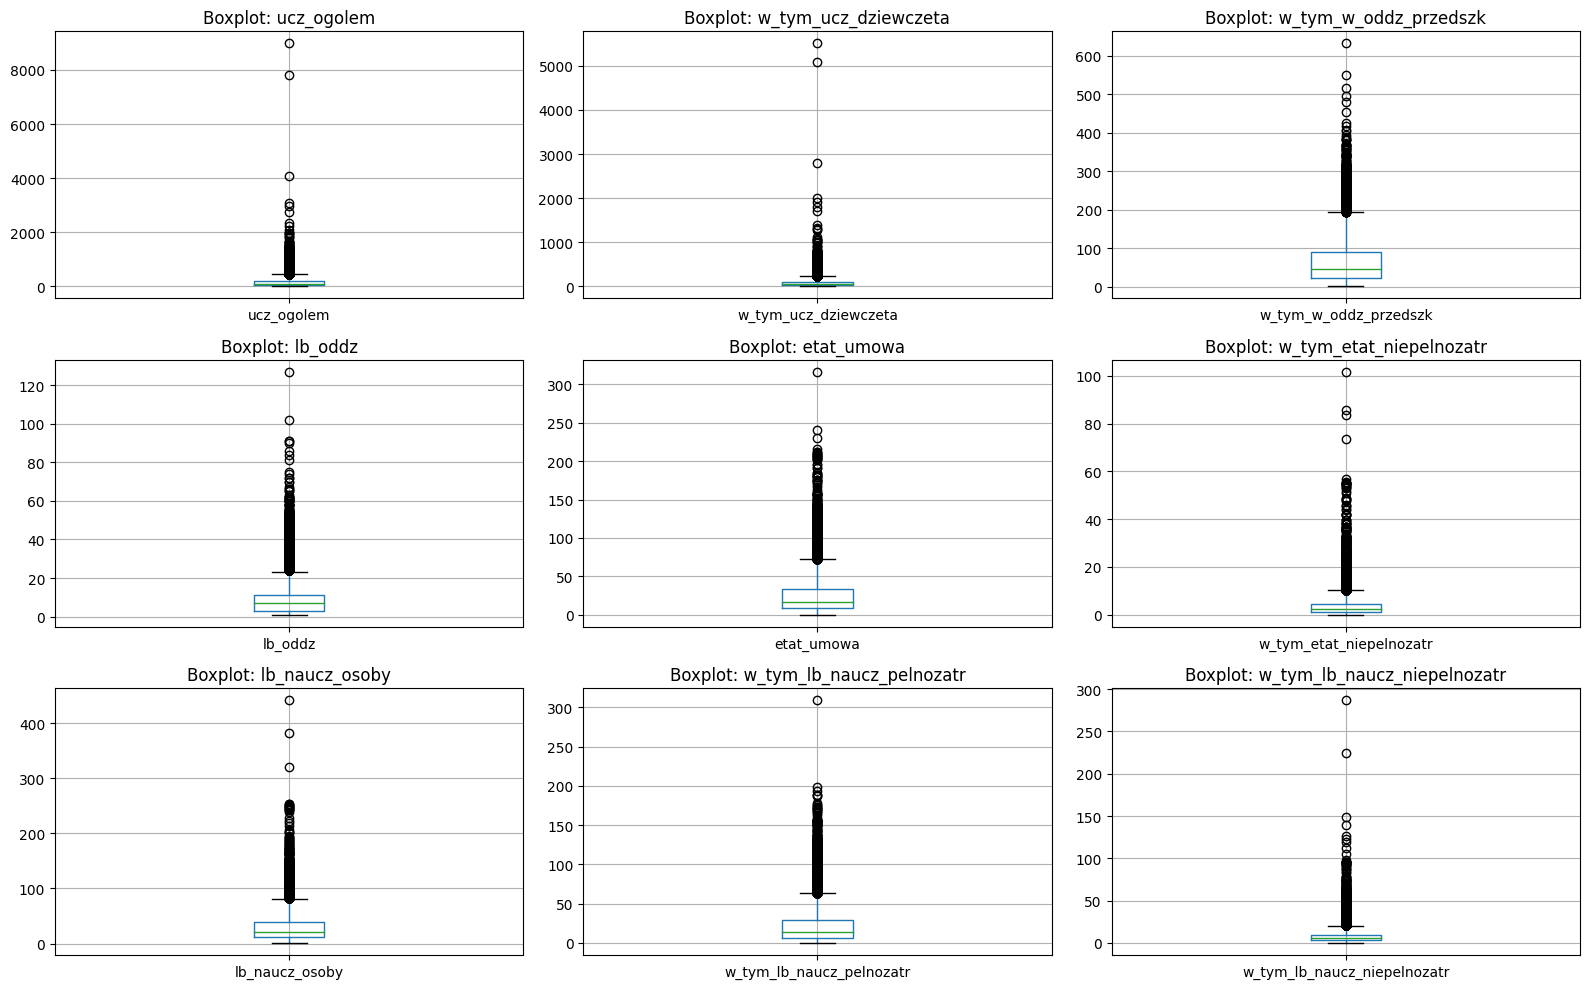

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_iqr):
    df_clean.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

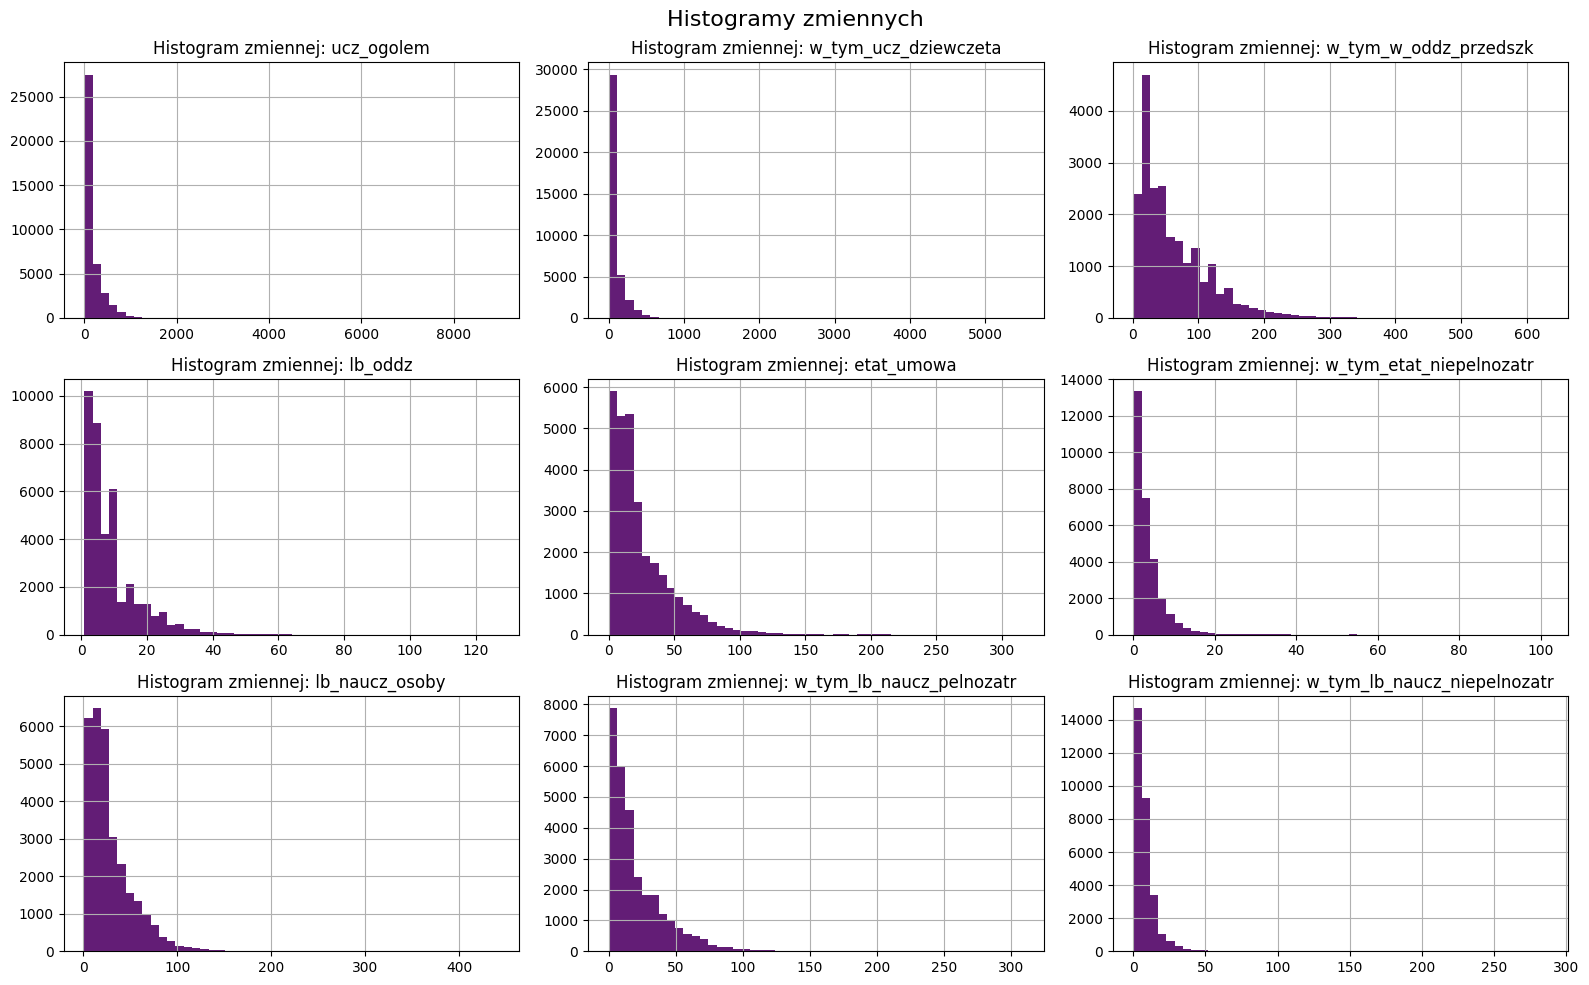

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_iqr):
    df_clean[col].hist(bins=50, ax=axes[i], color = '#631D76')
    axes[i].set_title(f"Histogram zmiennej: {col}")

fig.suptitle("Histogramy zmiennych", fontsize=16)
plt.tight_layout()
plt.show()

### Weryfikacja metody 3 sigm

In [18]:
mean = df_clean["ucz_ogolem"].mean()
std = df_clean["ucz_ogolem"].std()

lower = mean - 3 * std
upper = mean + 3 * std

within_range = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

percentage = len(within_range) / len(df_clean) * 100

print(f"Procent danych w zakresie 3σ: {percentage:.2f}%")
print(f"Procent outlierów: {100 - percentage:.2f}%")

Procent danych w zakresie 3σ: 53.42%
Procent outlierów: 46.58%


Analiza histogramów oraz wykresów pudełkowych pokazała, że wszystkie zmienne liczbowe charakteryzują się silną asymetrią prawostronną oraz obecnością licznych wartości odstających, czyli tzw. „długich ogonów”. Rozkłady danych nie mają charakteru normalnego, co wynika z naturalnego zróżnicowania wielkości placówek oświatowych w Polsce. Wartości odstające niekoniecznie stanowią błędy w danych, lecz mogą odzwierciedlać rzeczywiste różnice między małymi i dużymi jednostkami edukacyjnymi (na przykład szkoły wiejskie, a duże placówki miejskie).

Dla zmiennej "ucz_ogolem" wybranej jako przkładowa zmienna sprawdzono również udział obserwacji mieszczących się w przedziale wyznaczonym metodą 3σ. Otrzymane wyniki odbiegały od wartości charakterystycznych dla rozkładu normalnego (ok. 99,73% obserwacji w zakresie ±3σ, w tym przypadku jedynie ~69%), co potwierdza, że analizowane dane mają rozkład asymetryczny i zawierają długie ogony.

Z tego względu do identyfikacji wartości odstających zastosowano metodę rozstępu międzykwartylowego IQR, która dobrze sprawdza się w przypadku danych o takim rozkładzie i jest mniej wrażliwa na wartości skrajne niż średnia. Jednocześnie należy zaznaczyć, że wartości znajdujące się w „ogonach” rozkładów mogą być rzeczywiste i wynikać z naturalnego zróżnicowania szkół, dlatego ich ewentualne usuwanie należy traktować ostrożnie.

### Redukcja outlierów przy pomocy IQR

In [19]:
df_no_outliers = df_clean.copy()

for col in cols_iqr:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) &
        (df_no_outliers[col] <= upper)
    ]

In [20]:
print("Przed:", df_clean.shape)
print("Po:", df_no_outliers.shape)

Przed: (55741, 37)
Po: (12829, 37)


Zastosowano redukcję za pomocą meotyd IQR w sposób iteracyjny dla wszystkich zmiennych liczbowych - zapisano modyfikację w nowej zmiennej, aby móc w dalszej części porównać wyniki dla wersji z wartościami odstającymi oraz bez. Doprowadziło to jednak do znacznego ograniczenia liczby obserwacji (z 55 741 do 12 829), co oznacza usunięcie ponad 75% danych. Tak duża redukcja wskazuje, że podejście to jest zbyt restrykcyjne w kontekście analizowanego zbioru. Wynik ten potwierdza, że wartości uznane za odstające w wielu przypadkach nie są błędami, lecz odzwierciedlają rzeczywiste zróżnicowanie placówek oświatowych (np. różnice między małymi szkołami wiejskimi a dużymi szkołami miejskimi).

W związku z tym zdecydowano się **nie usuwać wartości odstających w sposób globalny**. Dalsza analiza oraz budowa modeli przeprowadzane będą na pełnym zbiorze danych (zawierającym outliery), aby zachować kompletną populację i uniknąć błędu selekcji. Podejście to pozwoli na uchwycenie wszystkich zjawisk zachodzących w oświacie, a ewentualny wpływ wartości ekstremalnych na wyniki zostanie uwzględniony na etapie interpretacji

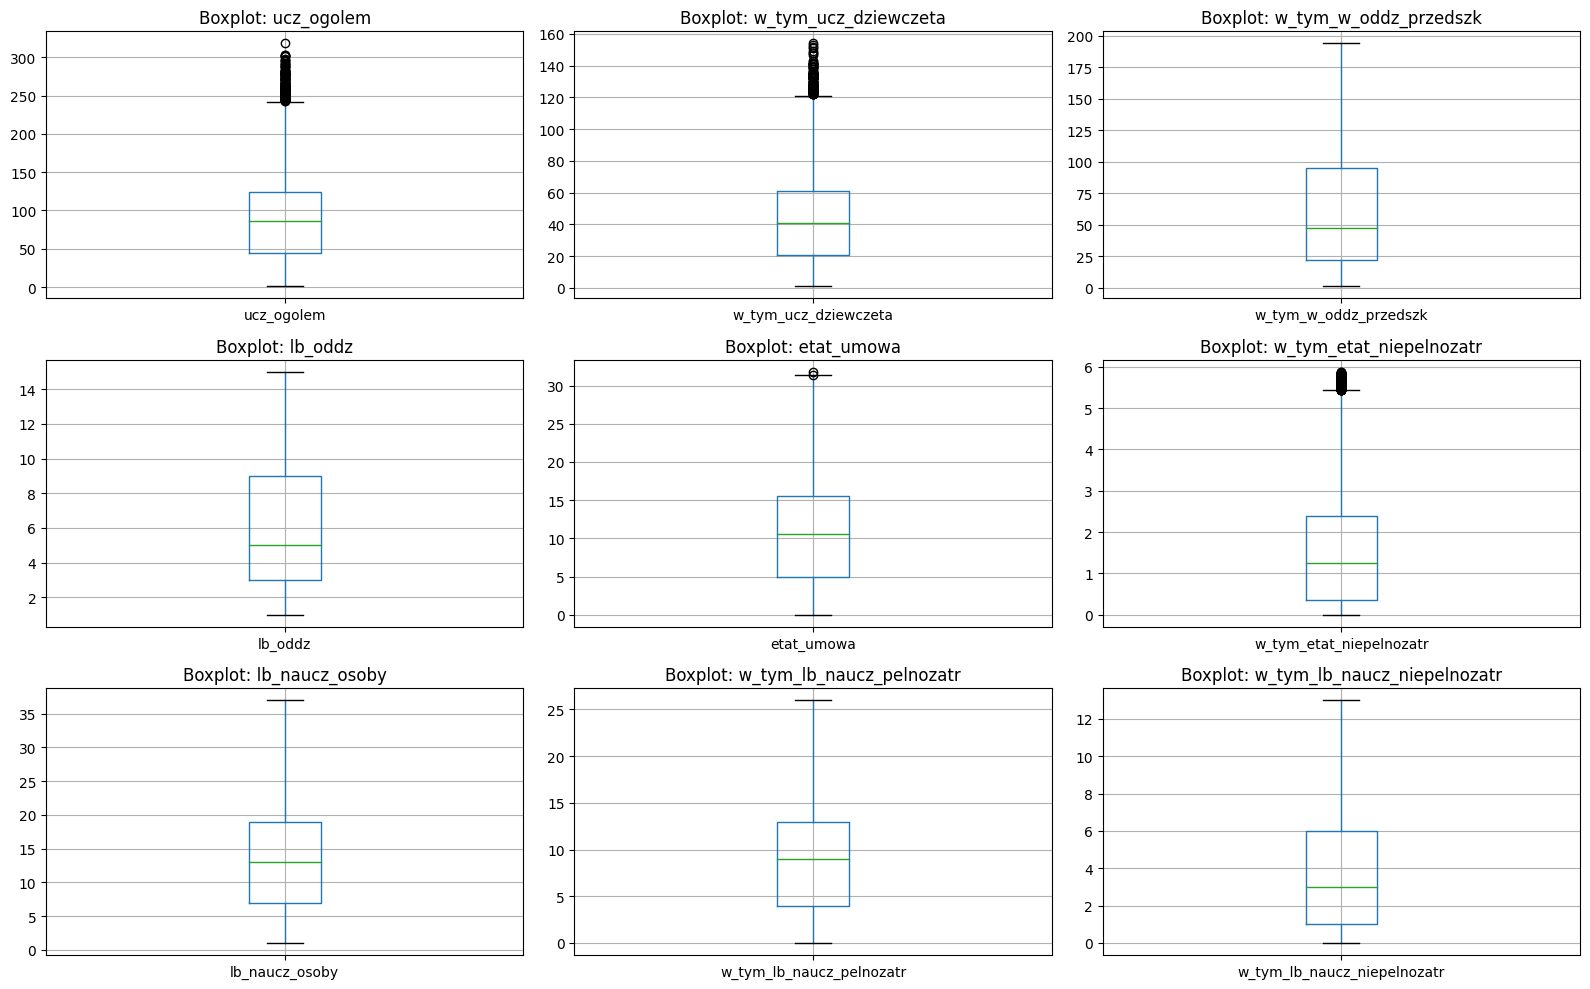

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_iqr):
    df_no_outliers.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

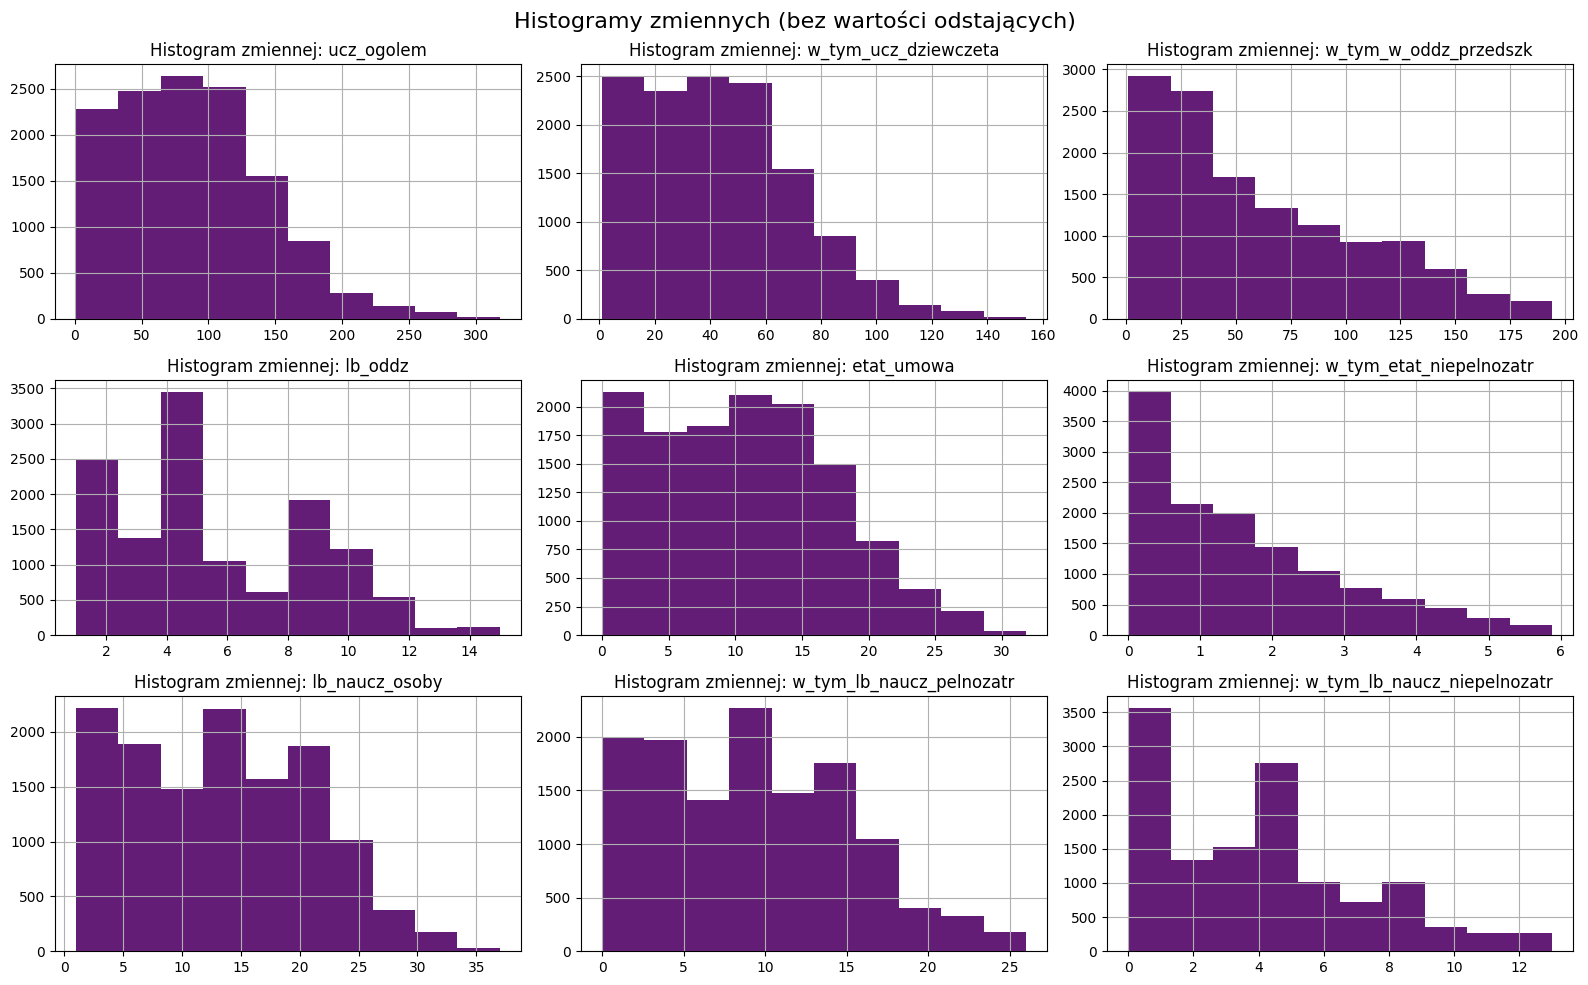

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_iqr):
    df_no_outliers[col].hist(bins=10, ax=axes[i], color = '#631D76')
    axes[i].set_title(f"Histogram zmiennej: {col}")

fig.suptitle("Histogramy zmiennych (bez wartości odstających)", fontsize=16)
plt.tight_layout()
plt.show()

Po usunięciu wartości odstających rozkłady zmiennych stały się bardziej skupione i czytelne, co ułatwia analizę typowych wartości. Jednocześnie nadal widoczna jest asymetria prawostronna, co wskazuje, że nie wynika ona wyłącznie z obecności wartości skrajnych, lecz jest cechą samego zbioru danych. Należy jednak podkreślić, że usunięcie wartości odstających doprowadziło do znacznego ograniczenia liczby obserwacji, a tym samym do utraty informacji o dużych placówkach edukacyjnych. W rezultacie uzyskany zbiór danych lepiej opisuje „przeciętną” szkołę, ale nie oddaje pełnego zróżnicowania systemu oświaty. W związku z tym analiza została przeprowadzona zarówno z uwzględnieniem, jak i bez uwzględnienia wartości odstających.

### Rozszerzony wariant IQR - 3.5
Dodatkowo, w celu oceny wpływu przyjętego progu identyfikacji wartości odstających, przeprowadzono analizę z wykorzystaniem rozszerzonego wariantu metody IQR, zwiększając współczynnik z 1.5 do 3.5. Celem było sprawdzenie, jak zmienia się liczba usuwanych obserwacji oraz wygląd rozkładów zmiennych przy mniej restrykcyjnym podejściu.

In [23]:
df_no_outliers = df_clean.copy()

for col in cols_iqr:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3.5 * IQR
    upper = Q3 + 3.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) &
        (df_no_outliers[col] <= upper)
    ]

In [24]:
print("Przed:", df_clean.shape)
print("Po:", df_no_outliers.shape)

Przed: (55741, 37)
Po: (14848, 37)


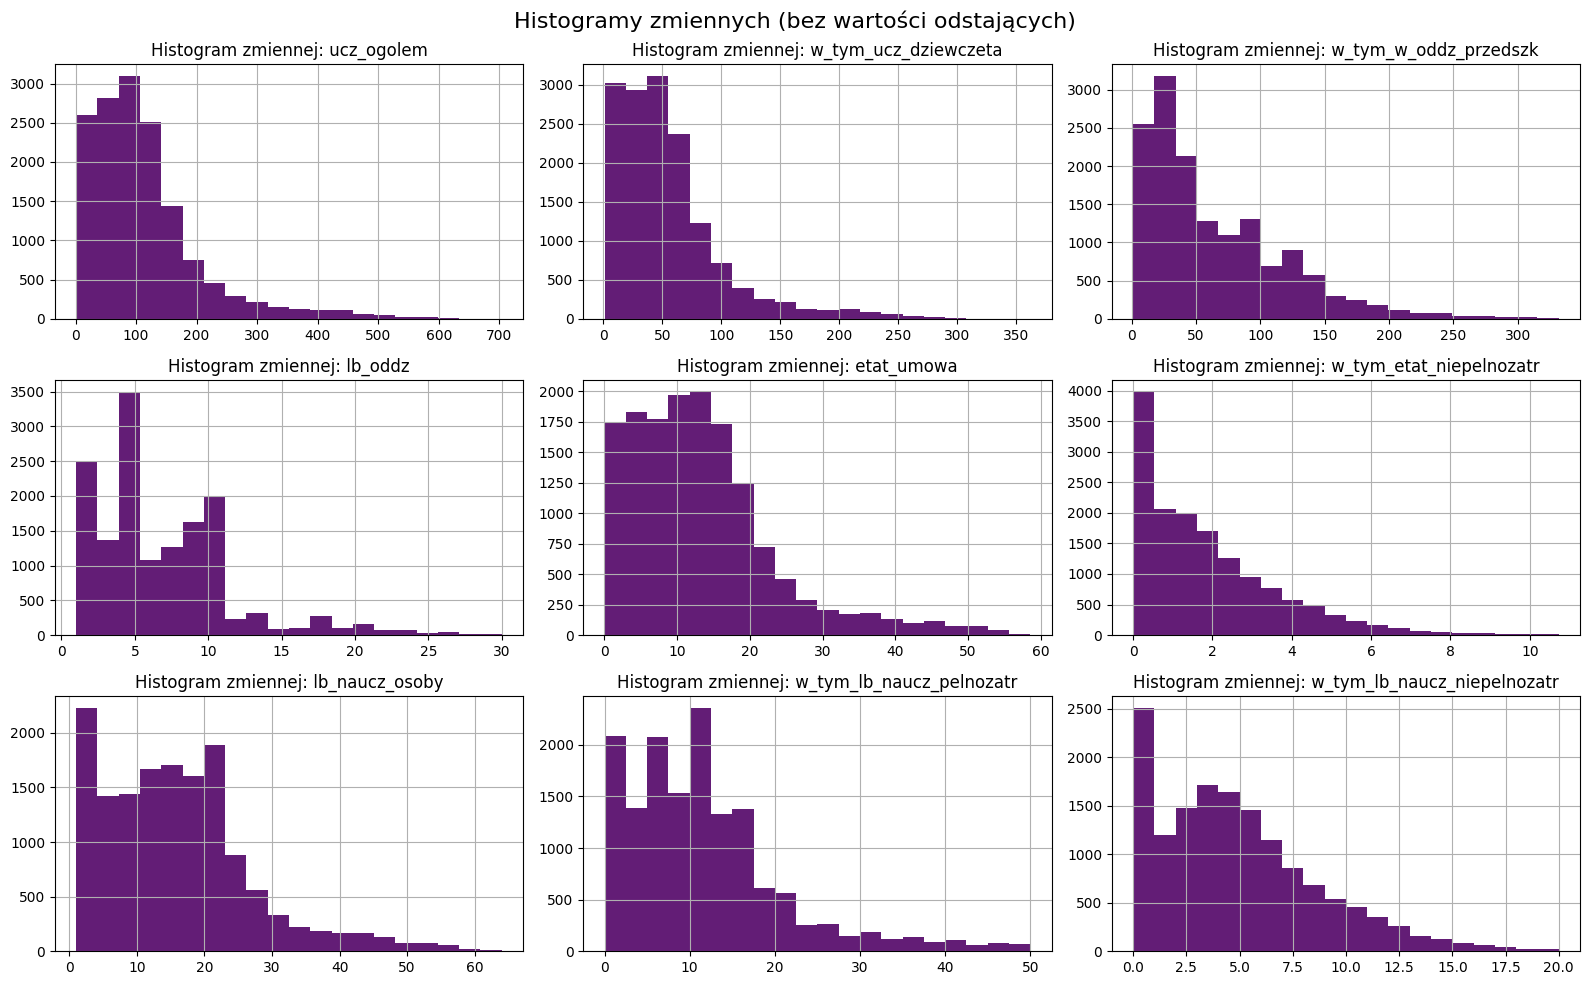

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_iqr):
    df_no_outliers[col].hist(bins=20, ax=axes[i], color = '#631D76')
    axes[i].set_title(f"Histogram zmiennej: {col}")

fig.suptitle("Histogramy zmiennych (bez wartości odstających)", fontsize=16)
plt.tight_layout()
plt.show()

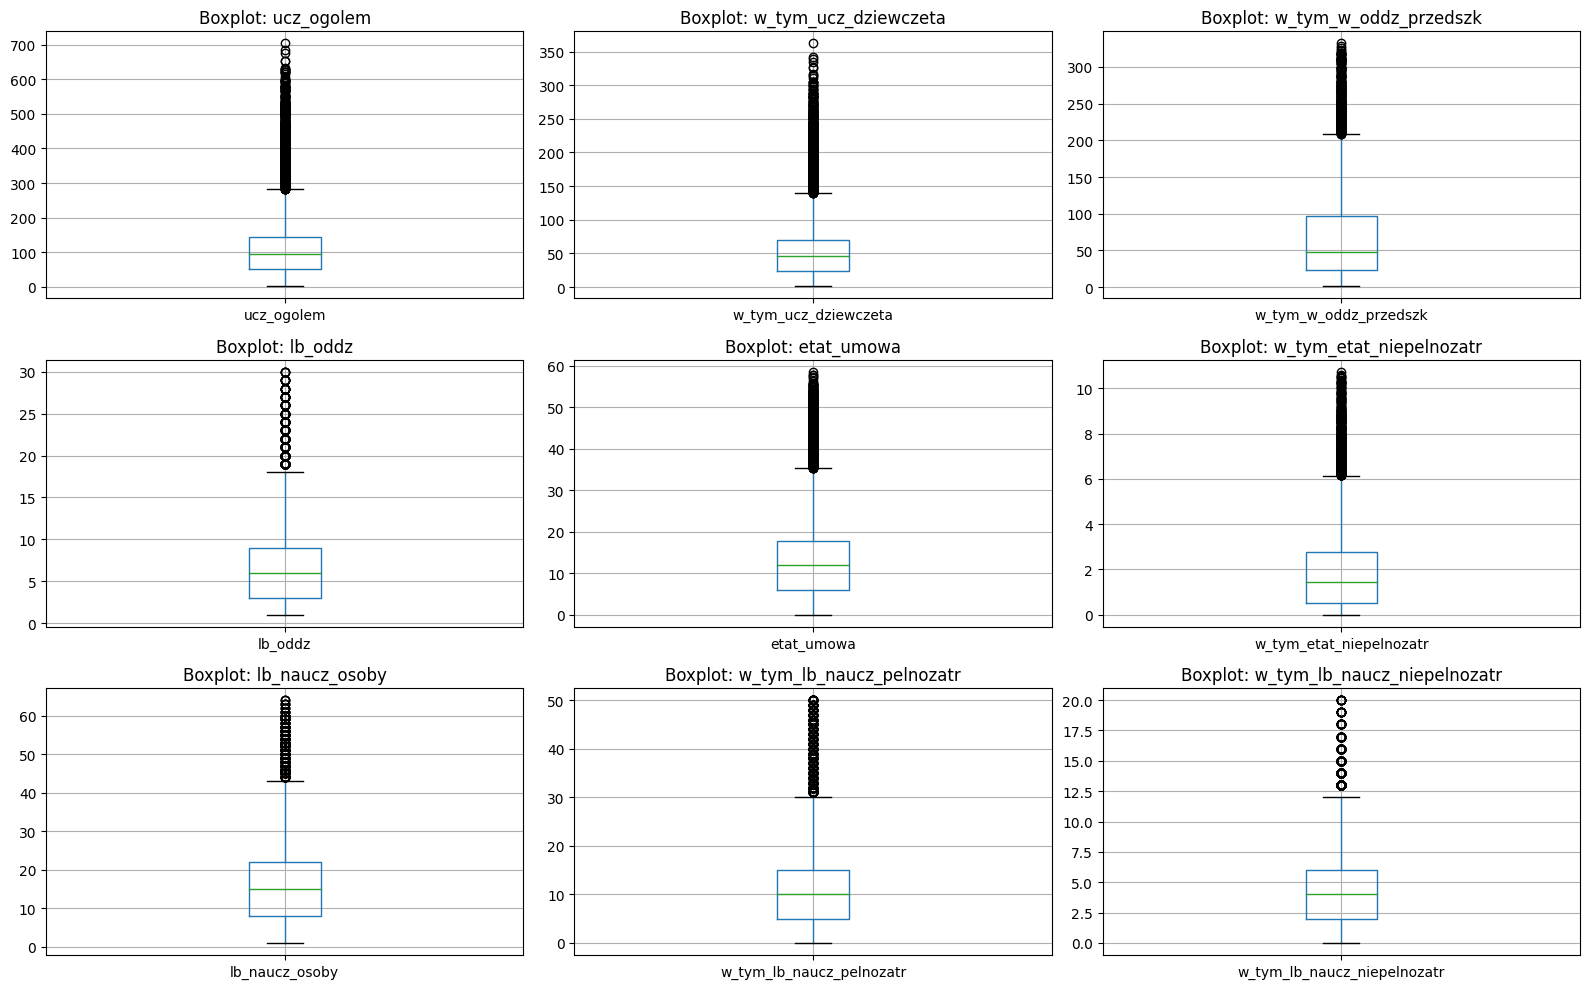

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_iqr):
    df_no_outliers.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

Zwiększenie zakresu metody IQR (do 3.5·IQR) pozwoliło na zachowanie większej liczby obserwacji w porównaniu do standardowego progu, jednak nadal prowadziło do istotnej redukcji zbioru danych

#### Wnioski
Etap przygotowania danych pozwolił na identyfikację i analizę braków danych oraz wartości odstających, a także ocenę ich wpływu na strukturę zbioru. Wykazano, że dane mają charakter rzeczywisty i silnie zróżnicowany, co jest typowe dla rejestrów administracyjnych. W związku z tym przyjęto podejście ostrożne, polegające na analizie danych głównie w wersji oryginalnej, ale także po ograniczeniu wpływu wartości odstających. Wyniki będą interpretowane z uwzględnieniem faktu, że wartości ekstremalne są integralną częścią badanej rzeczywistości, a nie błędem pomiarowym.

## 4. Statystyki opisowe

### 4.1 Zmienne ilościowe

W celu przeprowadzenia analizy statystycznej przygotowano funkcję obliczającą zestaw podstawowych oraz rozszerzonych statystyk opisowych dla wybranych zmiennych ilościowych. Analiza została wykonana na oryginalnym zbiorze danych.

In [27]:
cols_stats = [
    "ucz_ogolem",
    "w_tym_w_oddz_przedszk",
    "lb_oddz",
    "lb_naucz_osoby",
    "etat_umowa"
]

In [28]:
df_clean[cols_stats].describe()

,ucz_ogolem,w_tym_w_oddz_przedszk,lb_oddz,lb_naucz_osoby,etat_umowa
count,38968.000000,21804.000000,38968.000000,29777.000000,29777.000000
mean,173.268400,62.388736,9.120227,28.420358,24.386710
std,206.750761,54.112399,8.317477,25.275281,23.643584
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,47.000000,22.000000,3.000000,11.000000,8.320000
50%,103.000000,45.000000,7.000000,21.000000,16.810000
75%,212.000000,91.000000,11.000000,39.000000,33.990000
max,8978.000000,632.000000,127.000000,442.000000,316.450000


In [29]:
def calculate_stats(df, columns):
    results = []

    for col in columns:
        data = df[col].dropna()

        stats = {
            "zmienna": col,
            "średnia": data.mean(),
            "mediana": data.median(),
            "dominanta": data.mode()[0] if not data.mode().empty else None,
            "min": data.min(),
            "max": data.max(),
            "rozstęp": data.max() - data.min(),
            "Q1": data.quantile(0.25),
            "Q3": data.quantile(0.75),
            "IQR": data.quantile(0.75) - data.quantile(0.25), # rozstęp międzykwartylowy
            "wariancja": data.var(),
            "odchylenie_std": data.std(),
            "CV (%)": (data.std() / data.mean()) * 100 if data.mean() != 0 else None, #wsp. zmiennosci
            "skośność": data.skew(),
            "kurtoza": data.kurtosis()
        }

        results.append(stats)

    return pd.DataFrame(results).set_index("zmienna")

In [30]:
df_stats = calculate_stats(df_clean, cols_stats)
df_stats

,średnia,mediana,dominanta,min,max,rozstęp,Q1,Q3,IQR,wariancja,odchylenie_std,CV (%),skośność,kurtoza
zmienna,,,,,,,,,,,,,,
ucz_ogolem,173.268400,103.00,25.0,1.0,8978.00,8977.00,47.00,212.00,165.00,42745.877173,206.750761,119.323986,5.605435,143.548339
w_tym_w_oddz_przedszk,62.388736,45.00,25.0,1.0,632.00,631.00,22.00,91.00,69.00,2928.151771,54.112399,86.734245,1.749181,4.857233
lb_oddz,9.120227,7.00,4.0,1.0,127.00,126.00,3.00,11.00,8.00,69.180428,8.317477,91.198140,2.061818,7.118139
lb_naucz_osoby,28.420358,21.00,1.0,1.0,442.00,441.00,11.00,39.00,28.00,638.839850,25.275281,88.933719,2.201781,10.645817
etat_umowa,24.386710,16.81,1.0,0.0,316.45,316.45,8.32,33.99,25.67,559.019079,23.643584,96.952745,2.046195,6.937551


### Wnioski ogólne
* Analiza statystyk opisowych wykazała, że wszystkie zmienne charakteryzują się asymetrią prawostronną (średnia > mediana) oraz wysoką zmiennością. Największa zmienność występuje w przypadku zmiennej **ucz_ogolem**, co potwierdza bardzo wysoka wartość wariancji i odchylenia standardowego.
* Wartości dominanty dla analizowanych zmiennych przyjmują stosunkowo niskie wartości, co wynika z dużej liczby małych placówek w zbiorze danych. Sprawdzono (poniżej) przykładowe placówki z niewielką liczbą uczniów, aby sprawdzić czy dane mają sens. W większości są to placówki przedszkolne lub szkoły specjalne (np. branżowe).

### Wnioski dla konkretnych kolumn
#### UCZ_OGOLEM - Całkowita liczba uczniów
Zmienna charakteryzuje się bardzo dużym zróżnicowaniem. Średnia wartość jest istotnie wyższa od mediany, co wskazuje na silną asymetrię prawostronną. Większość placówek jest stosunkowo niewielka, natomiast istnieje grupa dużych placówek, które znacząco zawyżają średnią (jest ich niewiele). Wysoki **współczynnik zmienności** potwierdza dużą różnorodność wielkości szkół w analizowanym zbiorze. Wysoka kurtoza wskazuje na ogromną liczbę wartości skrajnych, co było również widoczne na histogramie. CV powyżej 100 % wskazuje na duży rozrzut danych.


#### W_TYM_W_ODDZ_PRZEKSZK - Liczba w oddziałach przedszkolnych
Zmienna dotycząca liczby dzieci w oddziałach przedszkolnych również wykazuje asymetrię prawostronną oraz stosunkowo wysoką zmienność. Wynika to z faktu, że oddziały przedszkolne występują prawdopodobnie tylko w części placówek, a dodatkowo ich liczebność może się znacznie różnić. W obu analizowanych zmiennych (**ucz_ogolem** oraz **w_tym_w_oddz_przedszk**) dominanta przyjmuje tę samą wartość (25). Może to wskazywać na pewną powtarzalność liczebności w mniejszych placówkach, aczkolwiek są to niepodparte wnioski.

#### LB_ODDZ - Liczba oddziałów w placówce
Liczba oddziałów ma najmniejszy rozstęp ze wszystkich analizowanych zmiennych. Większość szkół posiada niewielką liczbę oddziałów. Wykazuje umiarkowanie wysoką zmienność. Zmienna ta dobrze odzwierciedla organizacyjną skalę działania placówek. Średnia liczba oddziałów jest stosunkowo niska (około 9), co wskazuje, że przeciętna placówka nie jest rozbudowaną jednostką organizacyjną. Mediana na poziomie 7 dodatkowo potwierdza, że większość szkół posiada niewielką liczbę oddziałów.

#### LB_NAUCZ_OSOBY - Liczba nauczycieli
Liczba nauczycieli w placówkach wykazuje duże zróżnicowanie oraz asymetrię prawostronną. W większości szkół zatrudniona jest stosunkowo niewielka liczba nauczycieli, natomiast większe placówki posiadają znacznie rozbudowaną kadrę (maksymalna liczba 442 osób nauczających). Jednostki mają mocno zróżnicowaną liczebność kadrową. Odchylenie standardowo ma wartość bliską średniej.

#### ETAT_UMOWA - Liczba nauczycieli na etacie
Zmienna dotycząca liczby etatów nauczycielskich wskazuje podobne właściwości do zmiennej **lb_naucz_osoby**. Również charakteryzuje się dużą zmiennością oraz asymetrią prawostronną. W porównaniu do liczby nauczycieli, wartości tej zmiennej lepiej oddają rzeczywisty udział kadry w placówkach. Warto zauważyć, że średnia liczba etatów jest niższa niż średnia liczba nauczycieli, co sugeruje, że część kadry pracuje w niepełnym wymiarze czasu pracy. Minimum wskazuje, że istnieją placówki, w których nie ma żadnej osoby nauczającej w wymiarze pełnego etatu.

In [31]:
df_clean[df_clean['ucz_ogolem'] == df_clean['ucz_ogolem'].max()]

,wojewodztwo,powiat,gmina,typ_gminy,miejscowosc,czy_szkola,rspo,typ_podmiotu,rodzaj_szkoly_placowki,nazwa_placowki,...,organ_rejestrujacy,ucz_ogolem,w_tym_ucz_dziewczeta,w_tym_w_oddz_przedszk,lb_oddz,etat_umowa,w_tym_etat_niepelnozatr,lb_naucz_osoby,w_tym_lb_naucz_pelnozatr,w_tym_lb_naucz_niepelnozatr
27797,MAZOWIECKIE,m. st. Warszawa,M. st. Warszawa,M,Bielany,1,275491,Liceum ogólnokształcące,samodzielna,I LICEUM W CHMURZE,...,MIASTO STOŁECZNE WARSZAWA,8978.0,5506.0,NaN,51.0,240.86,85.86,442.0,155.0,287.0


**Zidentyfikowano bardzo silną wartość odstającą w zmiennej dotyczącej liczby uczniów ogółem. Analiza wykazała, że nie jest to błąd pomiaru ani anomalia danych, lecz obserwacja rzeczywista, odnosząca się do działalności Liceum w Chmurze - zpopularyzowanej w ostatnim czasie metody nauczania domowego dla licealistów. Placówka ta funkcjonuje w modelu edukacji zdalnej i skupia wyjątkowo dużą liczbę uczniów, co znacząco odbiega od typowych wartości obserwowanych w pozostałych jednostkach. W konsekwencji obecność tej obserwacji istotnie wpływa na statystyki opisowe, w szczególności zawyżając średnią oraz zwiększając zróżnicowanie danych.**

In [32]:
df_clean[df_clean['lb_oddz'] == df_clean['lb_oddz'].max()]

,wojewodztwo,powiat,gmina,typ_gminy,miejscowosc,czy_szkola,rspo,typ_podmiotu,rodzaj_szkoly_placowki,nazwa_placowki,...,organ_rejestrujacy,ucz_ogolem,w_tym_ucz_dziewczeta,w_tym_w_oddz_przedszk,lb_oddz,etat_umowa,w_tym_etat_niepelnozatr,lb_naucz_osoby,w_tym_lb_naucz_pelnozatr,w_tym_lb_naucz_niepelnozatr
27977,MAZOWIECKIE,m. st. Warszawa,M. st. Warszawa,M,Wola,1,479167,Szkoła policealna,samodzielna,"PUBLICZNA SZKOŁA POLICEALNA ""COSINUS"" W WARSZAWIE",...,MIASTO STOŁECZNE WARSZAWA,4095.0,2797.0,NaN,127.0,2.73,1.73,5.0,1.0,4.0


**Zidentyfikowano także maksymalną wartość liczby oddziałów, która występuje w Publicznej Szkole Policealnej "Cosinus" w Warszawie. Nie jest to wynik błędu danych, lecz konsekwencja specyfiki tej placówki — szkoły policealne oferują szeroki wachlarz kierunków oraz trybów kształcenia (dzienny, zaoczny), co przekłada się na dużą liczbę oddziałów. Dodatkowo funkcjonują one w dużych miastach i obsługują znaczną liczbę słuchaczy, co uzasadnia obserwowaną wartość maksymalną. W związku z tym analizowana obserwacja stanowi przykład uzasadnionej wartości skrajnej wynikającej z charakteru działalności placówki.**

In [33]:
df_clean[df_clean["lb_naucz_osoby"] == 1].sample(5)

,wojewodztwo,powiat,gmina,typ_gminy,miejscowosc,czy_szkola,rspo,typ_podmiotu,rodzaj_szkoly_placowki,nazwa_placowki,...,organ_rejestrujacy,ucz_ogolem,w_tym_ucz_dziewczeta,w_tym_w_oddz_przedszk,lb_oddz,etat_umowa,w_tym_etat_niepelnozatr,lb_naucz_osoby,w_tym_lb_naucz_pelnozatr,w_tym_lb_naucz_niepelnozatr
3501,DOLNOŚLĄSKIE,m. Wrocław,M. Wrocław,M,Wrocław-Psie Pole,1,276715,Przedszkole,samodzielna,"PUBLICZNE PRZEDSZKOLE ""LIPI""",...,GMINA WROCŁAW,229.0,106.0,229.0,10.0,1.00,0.00,1.0,1.0,0.0
2461,DOLNOŚLĄSKIE,złotoryjski,Świerzawa,M-Gm,Nowy Kościół,1,68260,Punkt przedszkolny,samodzielna,PUNKT PRZEDSZKOLNY W SZKOLE PODSTAWOWEJ IM. JA...,...,GMINA ŚWIERZAWA,11.0,5.0,11.0,1.0,1.00,0.00,1.0,1.0,0.0
52548,WIELKOPOLSKIE,m. Leszno,M. Leszno,M,Leszno,1,276863,Szkoła policealna,samodzielna,"PUBLICZNA SZKOŁA POLICEALNA ""PASCAL"" W LESZNIE",...,LESZNO-MIASTO NA PRAWACH POWIATU,384.0,311.0,NaN,14.0,0.75,0.75,1.0,0.0,1.0
26520,MAZOWIECKIE,m. st. Warszawa,M. st. Warszawa,M,Białołęka,1,71185,Przedszkole,samodzielna,PRZEDSZKOLE NIEPUBLICZNE JAGÓDKA,...,MIASTO STOŁECZNE WARSZAWA,9.0,2.0,9.0,1.0,1.00,0.00,1.0,1.0,0.0
36605,POMORSKIE,wejherowski,Rumia,M,Rumia,1,68463,Przedszkole,samodzielna,„SŁONECZNA JEDYNKA” PRZEDSZKOLE NR 1,...,GMINA MIEJSKA RUMIA,50.0,22.0,50.0,2.0,0.25,0.25,1.0,0.0,1.0


**Zidentyfikowano przypadki placówek, w których liczba nauczycieli wynosi 1. Nie musi to oznaczać błędu w danych, lecz może wynikać ze specyfiki jednostek - są to głównie małe placówki, takie jak punkty przedszkolne lub niewielkie przedszkola niepubliczne, funkcjonujące w ograniczonej skali. W takich przypadkach jeden nauczyciel może prowadzić zajęcia w grupach łączonych lub pełnić kilka funkcji jednocześnie. Dodatkowo w szkołach dla dorosłych część kadry może być zatrudniona w niepełnym wymiarze godzin lub wykazywana w inny sposób w systemie sprawozdawczym.**

In [34]:
# Okolice dominanty - podobne wnioski jak powyżej
df_clean[
    (df_clean["ucz_ogolem"] >= 20) & (df_clean["ucz_ogolem"] <= 30)
].sample(5)

,wojewodztwo,powiat,gmina,typ_gminy,miejscowosc,czy_szkola,rspo,typ_podmiotu,rodzaj_szkoly_placowki,nazwa_placowki,...,organ_rejestrujacy,ucz_ogolem,w_tym_ucz_dziewczeta,w_tym_w_oddz_przedszk,lb_oddz,etat_umowa,w_tym_etat_niepelnozatr,lb_naucz_osoby,w_tym_lb_naucz_pelnozatr,w_tym_lb_naucz_niepelnozatr
55676,ZACHODNIOPOMORSKIE,m. Szczecin,M. Szczecin,M,Szczecin,1,481871,Przedszkole,samodzielna,NIEPUBLICZNE PRZESZKOLE Z ODDZIAŁAMI INTEGRACY...,...,GMINA MIASTO SZCZECIN,21.0,11.0,21.0,2.0,2.0,0.0,2.0,2.0,0.0
3300,DOLNOŚLĄSKIE,m. Wrocław,M. Wrocław,M,Wrocław-Fabryczna,1,129014,Punkt przedszkolny,samodzielna,"NIEPUBLICZNY PUNKT PRZEDSZKOLNY ""SEEDLINGS""",...,GMINA WROCŁAW,20.0,9.0,20.0,1.0,NaN,NaN,NaN,NaN,NaN
15326,MAŁOPOLSKIE,krakowski,Czernichów,Gm,Rybna,1,127551,Przedszkole,samodzielna,NIEPUBLICZNE PRZEDSZKOLE JĘZYKOWE AKADEMIA MAŁ...,...,GMINA CZERNICHÓW,27.0,14.0,27.0,2.0,2.0,0.0,2.0,2.0,0.0
17885,MAŁOPOLSKIE,tatrzański,Poronin,Gm,Stasikówka,1,480522,Szkoła podstawowa,filia szkoły lub placówki,SZKOŁA FILIALNA IM.KS.JERZEGO POPIEŁUSZKI W ST...,...,GMINA PORONIN,25.0,15.0,9.0,4.0,NaN,NaN,NaN,NaN,NaN
23240,MAZOWIECKIE,siedlecki,Kotuń,Gm,Cisie-Zagrudzie,1,131955,Przedszkole,samodzielna,"NIEPUBLICZNE PRZEDSZKOLE ,, LEŚNA KRAINA"" JOAN...",...,GMINA KOTUŃ,30.0,15.0,30.0,4.0,5.0,0.0,5.0,5.0,0.0


### 4.2 Zmienne jakościowe
W celu analizy zmiennych jakościowych wybrano zestaw zmiennych i przygotowano funkcję wyliczającą wymagane własności. Celowo wybrano zmienne z zerowymi brakami.

In [35]:
cols_cat = [
    "rodzaj_szkoly_placowki",
    "publicznosc",
    "wojewodztwo",
    "kategoria_uczniow",
    "typ_gminy"
]

In [36]:
def analyze_categorical_summary(df, columns):
    results = []

    for col in columns:
        counts = df[col].value_counts(dropna=False)
        percentages = df[col].value_counts(normalize=True, dropna=False) * 100
        
        mode_val = df[col].mode()[0] if not df[col].mode().empty else None
        mode_count = counts.loc[mode_val] if mode_val in counts else 0
        mode_pct = percentages.loc[mode_val] if mode_val in percentages else 0
        
        results.append({
            "zmienna": col,
            "liczba_unikalnych": df[col].nunique(),
            "dominanta": mode_val,
            "liczebność_dom": mode_count,
            "udział_dom (%)": round(mode_pct, 2),
            "braki_danych": df[col].isna().sum()
        })
    
    return pd.DataFrame(results).set_index("zmienna")

df_cat_summary = analyze_categorical_summary(df_clean, cols_cat)
display(df_cat_summary)

,liczba_unikalnych,dominanta,liczebność_dom,udział_dom (%),braki_danych
zmienna,,,,,
rodzaj_szkoly_placowki,4,samodzielna,33322,59.78,0
publicznosc,4,publiczna,37872,67.94,0
wojewodztwo,16,MAZOWIECKIE,8115,14.56,0
kategoria_uczniow,3,Dzieci lub młodzież,37422,67.14,0
typ_gminy,3,M,29468,52.87,0


#### Wnioski
* Placówki samodzielne dominują
* Dominacja publicznych placówek: W kolumnie publicznosc aż **67.94%** to szkoły publiczne. To bardzo silna dominanta.
* Zróżnicowanie gmin: Ponad połowa placówek **(52.87%)** znajduje się w gminach typu M (prawdopodobnie Miejskie)
* Liczba wojewodztw: liczba wskazuje, że dane odzwierciedlają całe terytorium Polski.
* Mazowieckie najczęstsze: Województwo mazowieckie stanowi **14.56%** zbioru, co sugeruje reprezentatywną próbkę (największe województwo ma najwięcej szkół).
* Na podstawie powyższych danych można przyjąć, że typowa placówka w analizowanym zbiorze to samodzielna, publiczna szkoła dla dzieci i młodzieży, zlokalizowana w gminie miejskiej na terenie województwa mazowieckiego.

In [37]:
def analyze_categorical_df(df, columns):
    all_summaries = []

    for col in columns:
        counts = df[col].value_counts(dropna=False)
        percentages = (df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        
        summary = pd.DataFrame({
            "liczebność": counts,
            "udział (%)": percentages
        })
        
        mode_val = df[col].mode()[0] if not df[col].mode().empty else None
        summary['czy_dominanta'] = summary.index == mode_val
        
        summary.index = pd.MultiIndex.from_product([[col], summary.index], names=['zmienna', 'kategoria'])
        
        all_summaries.append(summary)

    return pd.concat(all_summaries)

df_cat_summary = analyze_categorical_df(df_clean, cols_cat)
display(df_cat_summary)

liczebność  \
zmienna                kategoria                                                        
rodzaj_szkoly_placowki samodzielna                                              33322   
                       szkoła/placówka wchodząca w skład jednostki zło...       15847   
                       jednostka złożona                                         6095   
                       filia szkoły lub placówki                                  477   
publicznosc            publiczna                                                37872   
                       niepubliczna                                             17581   
                       niepubliczna szkoła artystyczna o uprawnieniach...         147   
                       niepubliczna szkoła artystyczna bez uprawnień p...         141   
wojewodztwo            MAZOWIECKIE                                               8115   
                       ŚLĄSKIE                                                   6042   
                       MAŁOPOLSKIE                                               5589   
                       WIELKOPOLSKIE                                             5343   
                       DOLNOŚLĄSKIE                                              3816   
                       PODKARPACKIE                                              3415   
                       POMORSKIE                                                 3387   
                       ŁÓDZKIE                                                   3369   
                       LUBELSKIE                                                 3138   
                       KUJAWSKO-POMORSKIE                                        2796   
                       ZACHODNIOPOMORSKIE                                        2222   
                       WARMIŃSKO-MAZURSKIE                                       2087   
                       ŚWIĘTOKRZYSKIE                                            1905   
                       PODLASKIE                                                 1624   
                       OPOLSKIE                                                  1523   
                       LUBUSKIE                                                  1370   
kategoria_uczniow      Dzieci lub młodzież                                      37422   
                       Bez kategorii                                            17015   
                       Dorośli                                                   1304   
typ_gminy              M                                                        29468   
                       M-Gm                                                     13709   
                       Gm                                                       12564   

                                                                           udział (%)  \
zmienna                kategoria                                                        
rodzaj_szkoly_placowki samodzielna                                              59.78   
                       szkoła/placówka wchodząca w skład jednostki zło...       28.43   
                       jednostka złożona                                        10.93   
                       filia szkoły lub placówki                                 0.86   
publicznosc            publiczna                                                67.94   
                       niepubliczna                                             31.54   
                       niepubliczna szkoła artystyczna o uprawnieniach...        0.26   
                       niepubliczna szkoła artystyczna bez uprawnień p...        0.25   
wojewodztwo            MAZOWIECKIE                                              14.56   
                       ŚLĄSKIE                                                  10.84   
                       MAŁOPOLSKIE                                              10.03   
                       WIELKOPOLSKIE                                 

### Wnioski dla konkretnych kolumn
#### RODZAJ_SZKOLY_PLACOWKI - Rodzaj szkoły i placówki
Odnotowano, że dominującą formą organizacyjną są **jednostki samodzielne, stanowiące blisko 60% całego zbioru**. Istotnym elementem struktury są również placówki wchodzące w skład jednostek złożonych (28,43%), co wskazuje na powszechność łączenia szkół w zespoły (np. zespoły szkolno-przedszkolne).

#### PUBLICZNOSC - Publiczność placówki
W danych wskazano 4 wyróżnione kategorie publiczności, z czego dwie intuicyjnie odpowiadają **publicznej i niepublicznej placówce**, a dwie pozostałe dotyczą jednostek artystycznych. Stwierdzono wyraźną przewagę sektora publicznego - **67,94% badanych placówek to szkoły publiczne**. Sektor niepubliczny obejmuje niespełna jedną trzecią zbioru (31,54%). Udział niepublicznych szkół artystycznych jest śladowy (łącznie ok. 0,5%), co pozwala przyjąć, że analizowane dane reprezentują głównie standardowy system oświatowy.

#### WOJEWODZTWO - Nazwa województwa
W obszarze rozkładu terytorialnego zaobserwowano znaczną koncentrację placówek w trzech regionach: **mazowieckim (14,56%), śląskim (10,84%) oraz małopolskim (10,03%)** - razem stanowią one ponad 30% całych danych. Najmniejszą reprezentację w zbiorze wykazują województwa lubuskie oraz opolskie (poniżej 3% każde). Jest to spójne z ogólną gęstością zaludnienia w Polsce, co potwierdza wysoką reprezentatywność danych.

#### KATEGORIA_UCZNIOW - Kategoria uczniów
Głównym odbiorcą usług edukacyjnych w analizowanym zbiorze są dzieci i młodzież **(67,14%)**. Znaczący udział stanowi również kategoria określona jako "Bez kategorii" (30,53%). Prawdopodobnie są to placówki o specyficznym profilu (np. przedszkola lub placówki wspomagające), co wymaga zachowania ostrożności przy wyciąganiu wniosków dotyczących wyłącznie systemowego nauczania szkolnego. Udział placówek dla dorosłych to jedynie **2,34%**.


#### TYP_GMINY - Grupy docelowe
W zbiorze danych dostępne są trzy rodzaje gmin - występuje w formie skrótowej (M, M-Gm, Gm), jednak na potrzeby analizy przyjęto ich pełną interpretację zgodnie z klasyfikacją rejestrową Głównego Urzędu Statystycznego. Struktura placówek według typu gminy wskazuje na **dominację gmin miejskich (52,87%)**, co sugeruje wysoką koncentrację zasobów edukacyjnych w miastach. Gminy o charakterze mieszanym (miejsko-wiejskie) oraz typowo wiejskie stanowią łącznie blisko połowę zbioru (ok. 47%). Takie zróżnicowanie podziału terytorialnego pozwala na przeprowadzenie rzetelnych porównań między dużą, zurbanizowaną infrastrukturą a mniejszymi ośrodkami, które mogą wykazywać odmienną dynamikę w zakresie liczby uczniów i obsady kadrowej.

## 5. Wizualizacje

W procesie przygotowania wizualizacji zrezygnowano z  generowania identycznych wykresów dla wszystkich dostępnych kolumn. Zamiast tego zastosowano podejście dedykowane, dobierając typ wizualizacji indywidualnie do charakteru zmiennej (ilościowej lub jakościowej) oraz roli, jaką odgrywa ona w strukturze polskiego systemu oświaty. Takie podejście pozwala na wyeksponowanie istotnych trendów, wykrycie korelacji oraz lepszą interpretację wartości odstających, które stanowią integralną część badanej rzeczywistości, co wykazano już we wcześniejszych sekcjach. Wybór indywidualnego podejścia wynikał również z ciekawości co do danych, a także wcześniej wyświetlonych histogramów oraz boxplotów dla wszystkich zmiennych liczbowych. Często zastosowano ograniczenie danych lub dane bez outlierów przygotowane wcześniej.

#### Rozkład liczebności uczniów
Jako pierwszą poddano analizie zmienną **ucz_ogolem** (łączna liczba uczniów w placówce). Jest to kluczowa zmienna ilościowa, która determinuje wielkość jednostki. 

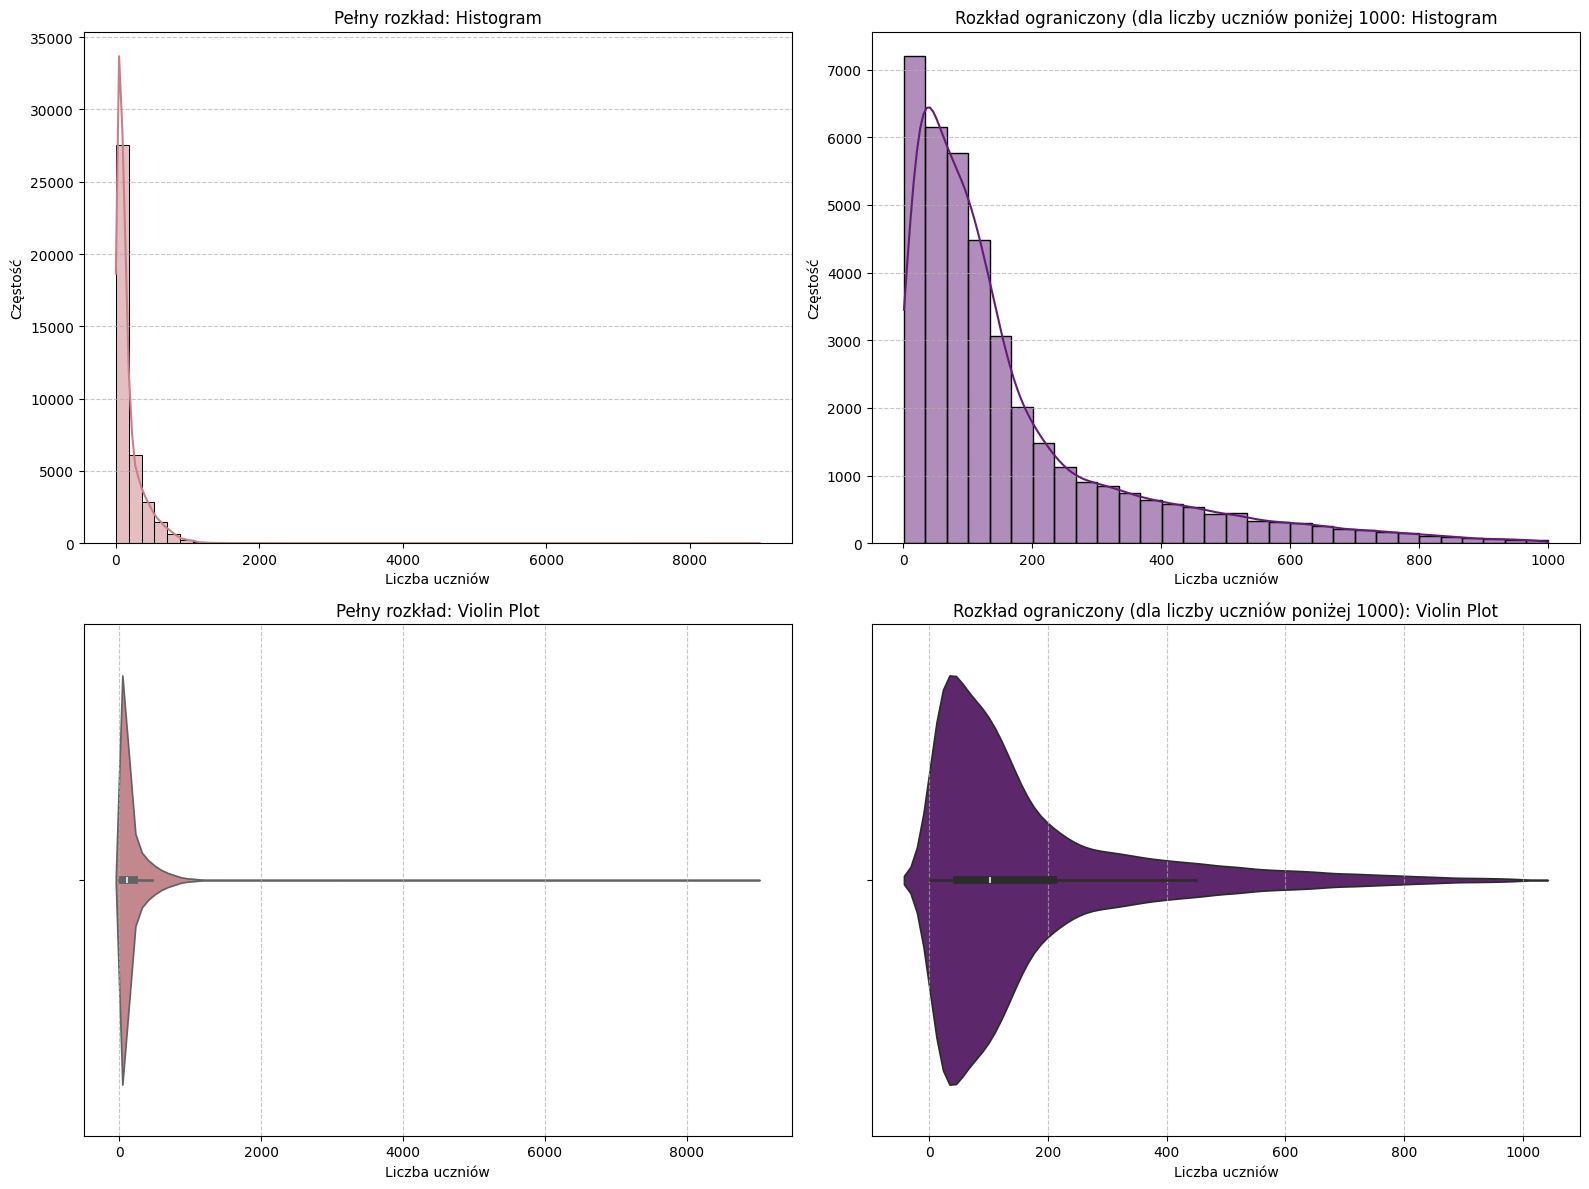

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# histogramy
sns.histplot(df_clean['ucz_ogolem'], bins=50, kde=True, color='#CC7E85', ax=axes[0, 0])
axes[0, 0].set_title('Pełny rozkład: Histogram')
axes[0, 0].set_xlabel('Liczba uczniów')
axes[0, 0].set_ylabel('Częstość')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

sns.histplot(df_clean[df_clean['ucz_ogolem'] < 1000]['ucz_ogolem'], bins=30, kde=True, color='#631D76', ax=axes[0, 1])
axes[0, 1].set_title('Rozkład ograniczony (dla liczby uczniów poniżej 1000: Histogram')
axes[0, 1].set_xlabel('Liczba uczniów')
axes[0, 1].set_ylabel('Częstość')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# violin ploty
sns.violinplot(x=df_clean['ucz_ogolem'], color='#CC7E85', ax=axes[1, 0])
axes[1, 0].set_title('Pełny rozkład: Violin Plot')
axes[1, 0].set_xlabel('Liczba uczniów')
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.7)

sns.violinplot(x=df_clean[df_clean['ucz_ogolem'] < 1000]['ucz_ogolem'], color='#631D76', ax=axes[1, 1])
axes[1, 1].set_title('Rozkład ograniczony (dla liczby uczniów poniżej 1000): Violin Plot')
axes[1, 1].set_xlabel('Liczba uczniów')
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

Wykres wykazuje silną asymetrię prawostronną. Dominują placówki małe i średnie, natomiast liczba jednostek dużych gwałtownie spada wraz ze wzrostem skali. Długi "ogon" rozkładu potwierdza obecność nielicznych, bardzo dużych kompleksów edukacyjnych - zarówno w histogramie na pełnych danych jak i przyciętych do maksymalnie 1000 uczniów.

### Boxplot: Liczba uczniów według typu gminy

Text(0, 0.5, 'Liczba uczniów (log)')

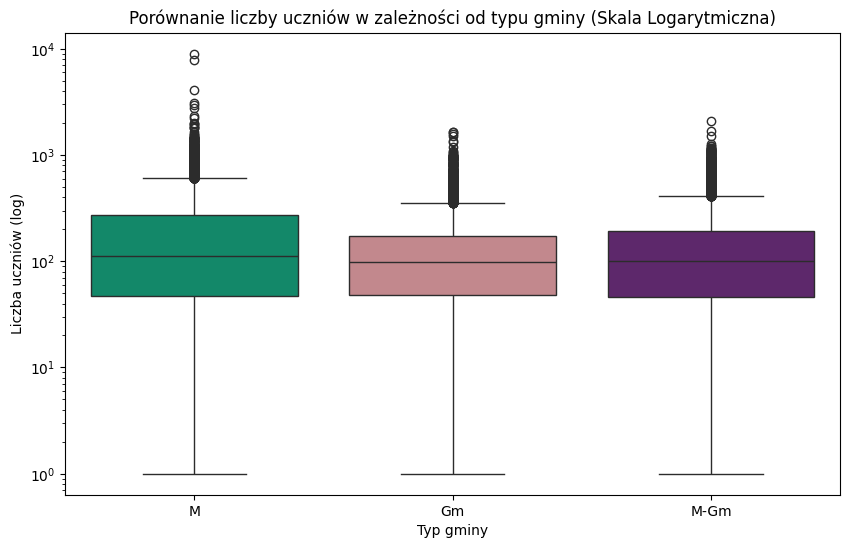

In [39]:
my_colors = ["#009B72", "#CC7E85", "#631D76"]

plt.figure(figsize=(10, 6))
sns.boxplot(x='typ_gminy', y='ucz_ogolem', data=df_clean, palette=my_colors)
plt.yscale('log') 
plt.title('Porównanie liczby uczniów w zależności od typu gminy (Skala Logarytmiczna)')
plt.xlabel('Typ gminy')
plt.ylabel('Liczba uczniów (log)')

Zastosowanie skali logarytmicznej pozwoliło na uwzględnienie szerokiego zakresu danych. Spodziewano się większych różnic w podziale na gminy - widać nieznacznie wyższą medianę dla szkół miejskich i charakteryzują się one najwyższą medianą oraz najbardziej rozbudowanym "ogonem" wartości ekstremalnych. Wiejskie natomiast mają najbardziej skondensowane wyniki (najmniej szerokie pudełko). Placówki z gmin Miejsko-Wiejskich (M-Gm) stanowią stadium pośrednie dla tych trzech kategorii.

### Histogram + Scatter plot: Analiza kadry - Porównanie zbioru pełnego i bez wartości odstających

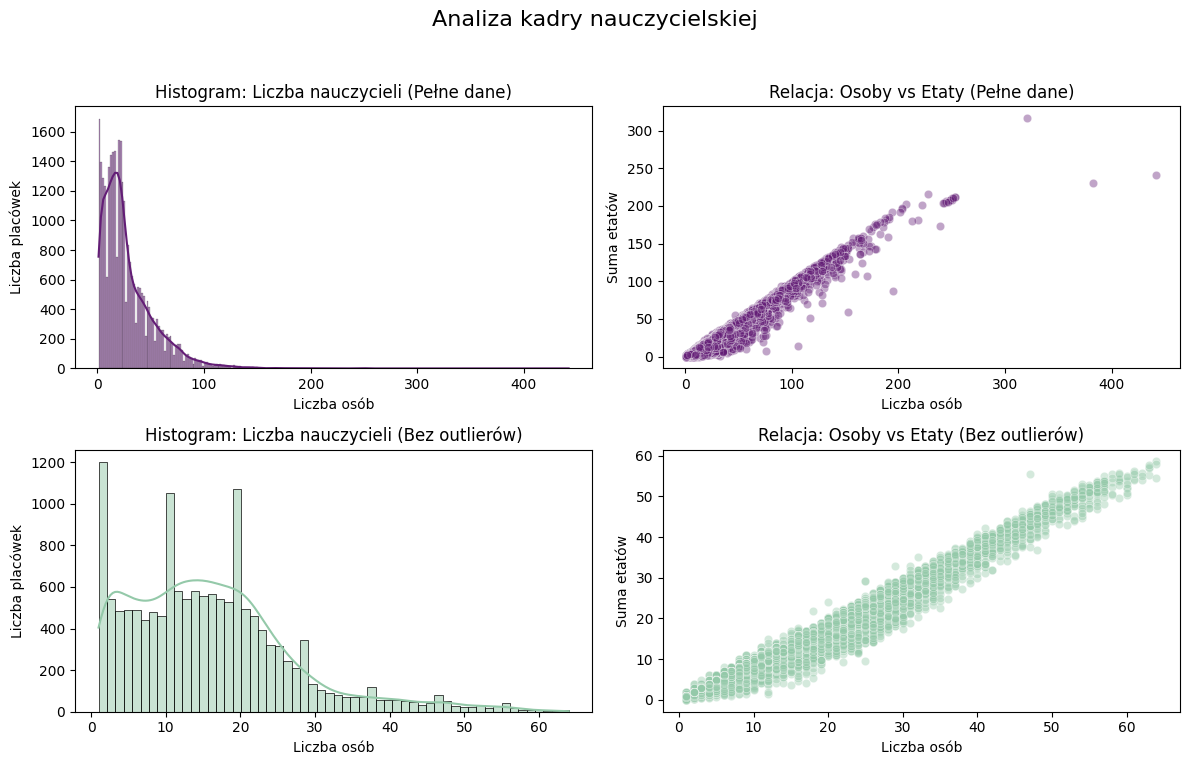

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_clean['lb_naucz_osoby'], kde=True, ax=axes[0, 0], color='#631D76')
axes[0, 0].set_title('Histogram: Liczba nauczycieli (Pełne dane)')
axes[0, 0].set_xlabel('Liczba osób')
axes[0, 0].set_ylabel('Liczba placówek')

sns.scatterplot(data=df_clean, x='lb_naucz_osoby', y='etat_umowa', ax=axes[0, 1], alpha=0.4, color='#631D76')
axes[0, 1].set_title('Relacja: Osoby vs Etaty (Pełne dane)')
axes[0, 1].set_xlabel('Liczba osób')
axes[0, 1].set_ylabel('Suma etatów')

sns.histplot(df_no_outliers['lb_naucz_osoby'], kde=True, ax=axes[1, 0], color='#94C9A9')
axes[1, 0].set_title('Histogram: Liczba nauczycieli (Bez outlierów)')
axes[1, 0].set_xlabel('Liczba osób')
axes[1, 0].set_ylabel('Liczba placówek')

sns.scatterplot(data=df_no_outliers, x='lb_naucz_osoby', y='etat_umowa', ax=axes[1, 1], alpha=0.4, color='#94C9A9')
axes[1, 1].set_title('Relacja: Osoby vs Etaty (Bez outlierów)')
axes[1, 1].set_xlabel('Liczba osób')
axes[1, 1].set_ylabel('Suma etatów')

plt.suptitle('Analiza kadry nauczycielskiej', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

Na wykresach pełnych (górny wiersz) rozkład jest silnie skompresowany przez nieliczne, ekstremalnie duże jednostki. Usunięcie outlierów (dolny wiersz) pozwoliło na wyeksponowanie struktury typowej placówki. Wykresy rozrzutu potwierdzają niemal idealną korelacje dodatnią między liczbą osób a sumą etatów. Histogramy wyraźnie pokazują, że system opiera się na dużej liczbie małych placówek, gdzie liczba nauczycieli nie przekracza 30-40 osób. Usunięcie outlierów pozwoliło dostrzec lokalne skoki liczebności (np. w okolicach 10 i 20 osób).

### Pie Chart: Struktura organizacyjna
Pokazuje udział procentowy części w całości, wybrano zmienną z niewielką liczbą wartości unikalnych, aby wykres był przejrzysty

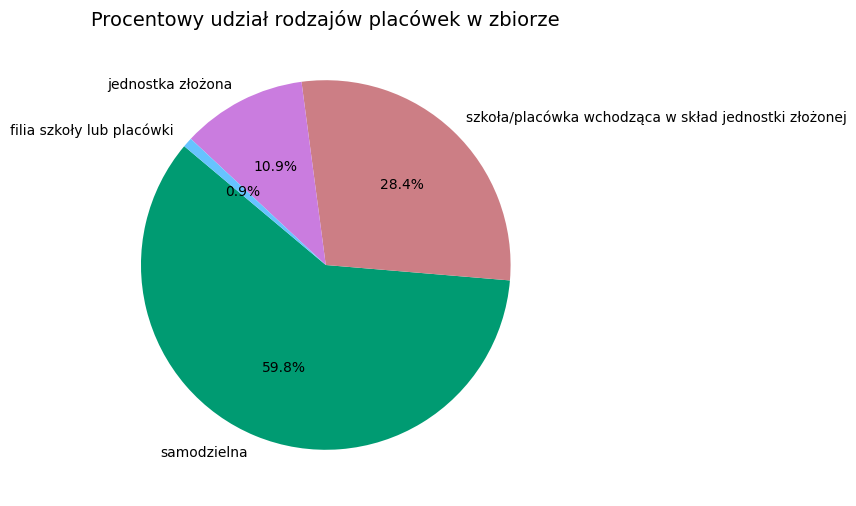

In [41]:
my_colors = ["#009B72", "#CC7E85", "#CA7CDF", "#66C3FF"]

plt.figure(figsize=(6, 6))
data = df_clean['rodzaj_szkoly_placowki'].value_counts()
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=140, colors=my_colors,)
plt.title('Procentowy udział rodzajów placówek w zbiorze', fontsize=14)
plt.show()

Największy wycinek (blisko 60%) stanowią **jednostki samodzielne**, co czyni je głównym przedmiotem analizy. Udział jednostek złożonych i ich filii jest znacznie mniejszy, co pozwala na stwierdzenie, że system oświatowy opiera się głównie na autonomicznych placówkach.

### Barplot: Liczba placówek w województwach

C:\Users\Iza\AppData\Local\Temp\ipykernel_16528\1436734801.py:6: UserWarning: 
The palette list has fewer values (4) than needed (16) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(


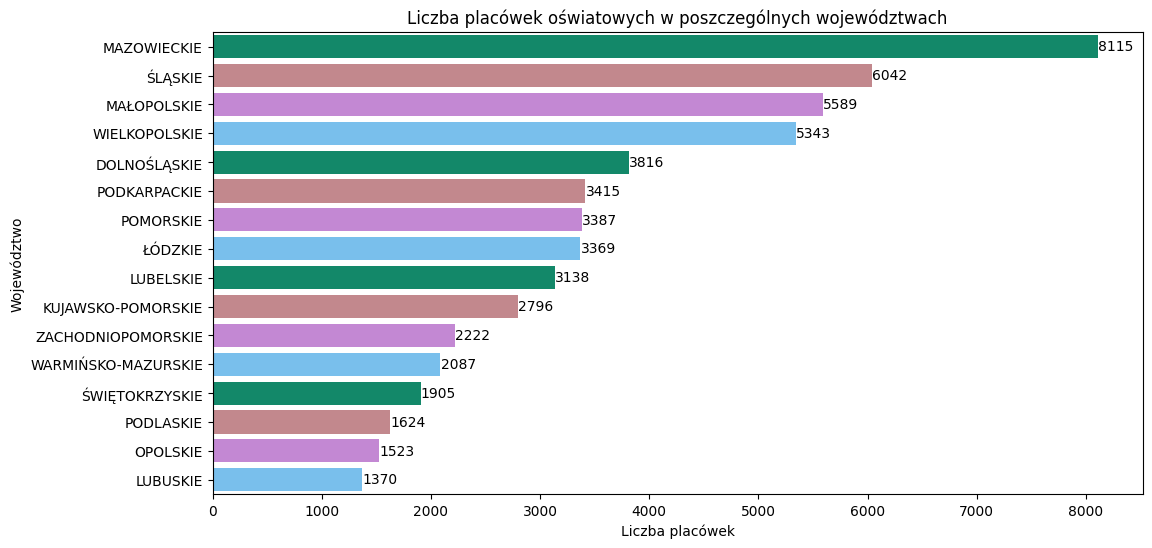

In [42]:
my_colors = ["#009B72", "#CC7E85", "#CA7CDF", "#66C3FF"]

plt.figure(figsize=(12, 6))
order = df_clean['wojewodztwo'].value_counts().index

ax = sns.countplot(
    y='wojewodztwo',
    data=df_clean,
    order=order,
    palette=my_colors
)

for i, v in enumerate(df_clean['wojewodztwo'].value_counts()):
    ax.text(v + 1, i, str(v), va='center')

plt.title('Liczba placówek oświatowych w poszczególnych województwach')
plt.xlabel('Liczba placówek')
plt.ylabel('Województwo')

plt.show()

Wykres słupkowy prezentuje ranking województw pod względem liczby placówek. Liczba placówek jest zróżnicowana w zależności od województwa. Największa liczba, odbiegająca od reszty, przypada na województwo mazowieckie, co wykazano już w statystykach opisowych. Widać też zależność od wielkości województwa i zaludnienia, natomiast to są informacje spoza tego zbioru.

### Stacked bar chart: flaga czy placówka jest szkołą

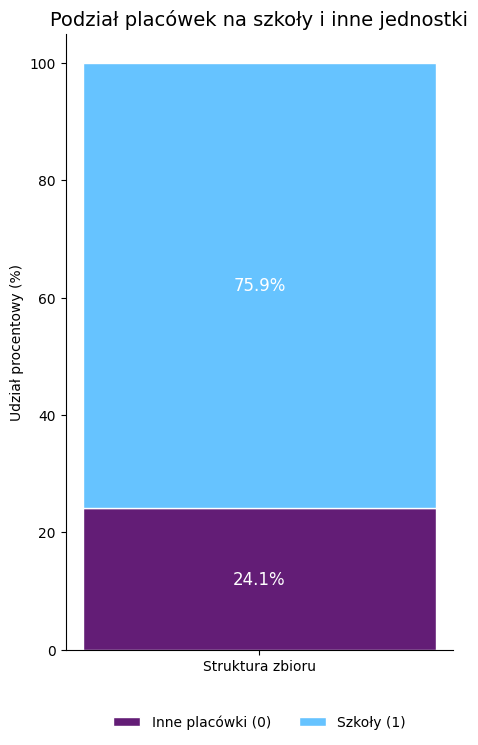

In [43]:
procenty = df_clean['czy_szkola'].value_counts(normalize=True).sort_index() * 100
pct_0 = procenty[0]
pct_1 = procenty[1]

fig, ax = plt.subplots(figsize=(5, 8))
#Stworzenie wykresu skumulowanego
ax.bar('Struktura zbioru', pct_0, color='#631D76', edgecolor='white', label='Inne placówki (0)')
ax.bar('Struktura zbioru', pct_1, bottom=pct_0, color='#66C3FF', edgecolor='white', label='Szkoły (1)')


ax.text(0, pct_0 / 2, f'{pct_0:.1f}%', ha='center', va='center', color='white', fontsize=12)
ax.text(0, pct_0 + (pct_1 / 2), f'{pct_1:.1f}%', ha='center', va='center', color='white', fontsize=12)

plt.title('Podział placówek na szkoły i inne jednostki', fontsize=14)
plt.ylabel('Udział procentowy (%)')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False) # Legenda pod wykresem

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

Ponad 75% placówek to szkoły, więc stanowią podstawę tej analizy. Co czwarta placówka (24,1%) sklasyfikowana została jako "inna". Ta znacząca mniejszość wskazuje na obecność w danych przedszkoli, poradni czy innych ośrodków wsparcia, co należy mieć na uwadze przy interpretacji średnich dla całego zbioru

### Analiza zbirocza: Ogół uczniów vs oddziały przedszkolne

C:\Users\Iza\AppData\Local\Temp\ipykernel_16528\3953414789.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1, 0].set_xticklabels(['Ogół uczniów', 'W oddz. przedszkolnych'])


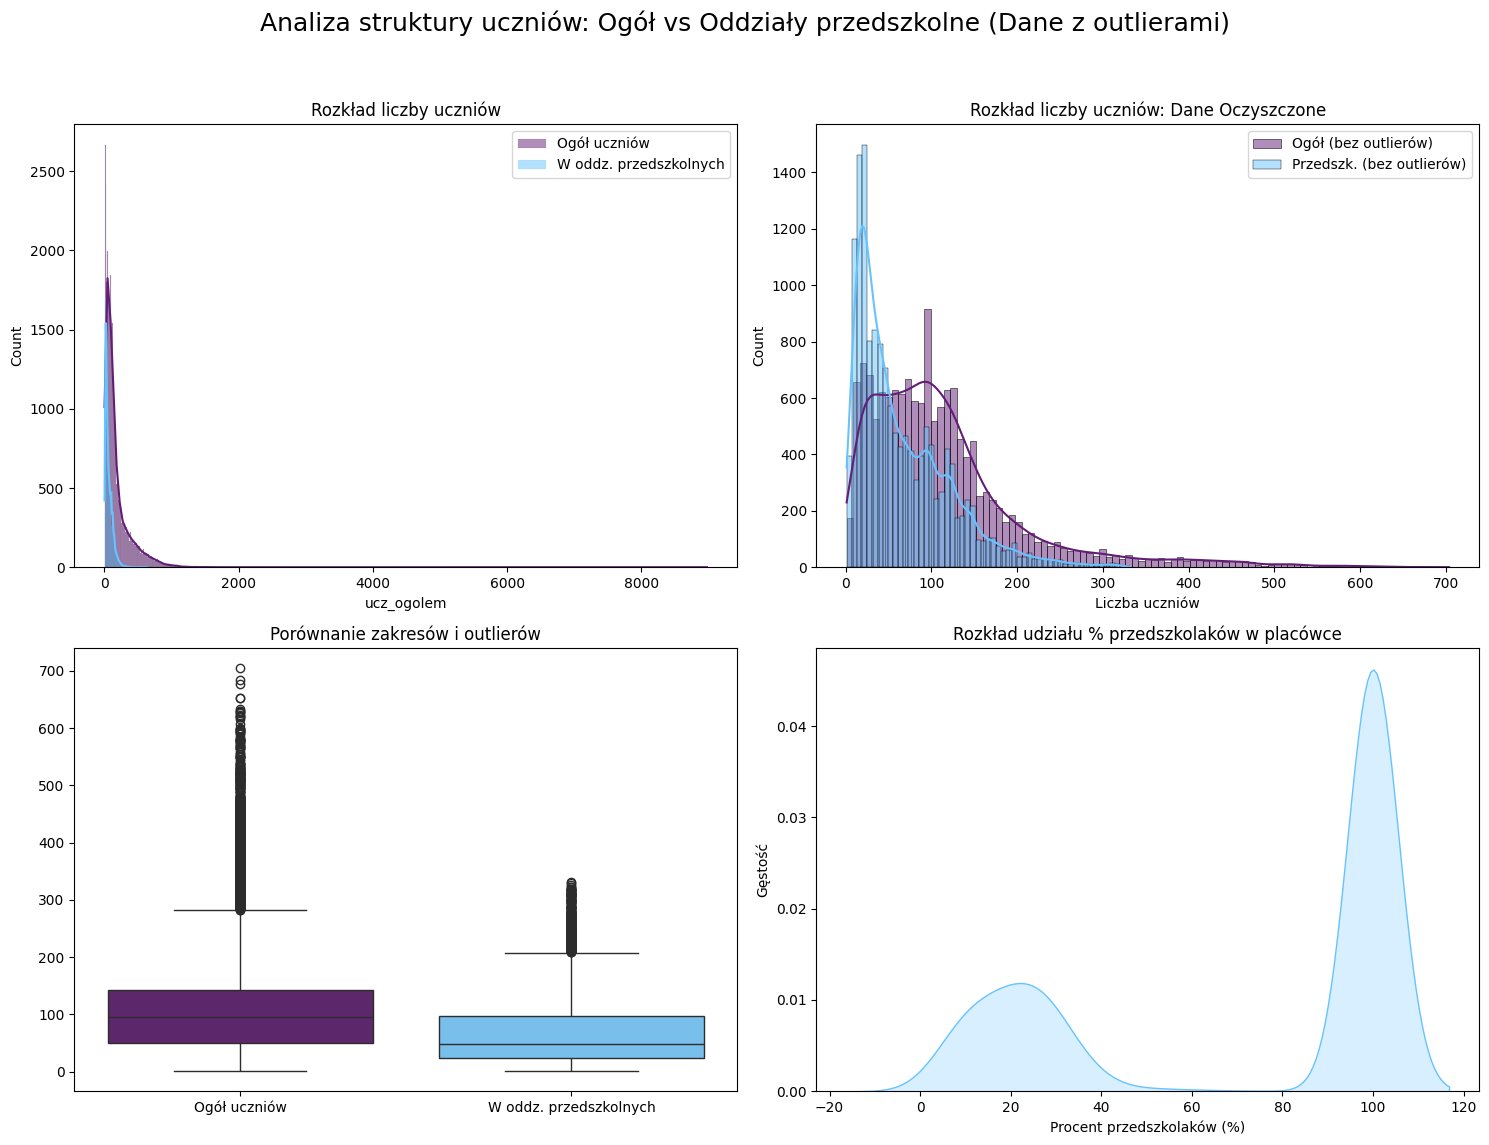

In [44]:
color_all = '#631D76'
color_pre = '#66C3FF'

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1
sns.histplot(df_clean['ucz_ogolem'], color=color_all, label='Ogół uczniów', kde=True, ax=axes[0, 0])
sns.histplot(df_clean['w_tym_w_oddz_przedszk'], color=color_pre, label='W oddz. przedszkolnych', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Rozkład liczby uczniów')
axes[0, 1].set_xlabel('Liczba uczniów')
axes[0, 0].legend()

# 2
sns.histplot(df_no_outliers['ucz_ogolem'], color=color_all, label='Ogół (bez outlierów)', kde=True, ax=axes[0, 1])
sns.histplot(df_no_outliers['w_tym_w_oddz_przedszk'], color=color_pre, label='Przedszk. (bez outlierów)', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Rozkład liczby uczniów: Dane Oczyszczone')
axes[0, 1].set_xlabel('Liczba uczniów')
axes[0, 1].legend()

# 3
sns.boxplot(data=df_no_outliers[['ucz_ogolem', 'w_tym_w_oddz_przedszk']], palette=[color_all, color_pre], ax=axes[1, 0])
axes[1, 0].set_title('Porównanie zakresów i outlierów')
axes[1, 0].set_xticklabels(['Ogół uczniów', 'W oddz. przedszkolnych'])

# 4
df_clean['pct_przedszk'] = (df_no_outliers['w_tym_w_oddz_przedszk'] / df_no_outliers['ucz_ogolem']) * 100
sns.kdeplot(df_clean['pct_przedszk'], fill=True, color=color_pre, ax=axes[1, 1])
axes[1, 1].set_title('Rozkład udziału % przedszkolaków w placówce')
axes[1, 1].set_xlabel('Procent przedszkolaków (%)')
axes[1, 1].set_ylabel('Gęstość')

plt.suptitle('Analiza struktury uczniów: Ogół vs Oddziały przedszkolne (Dane z outlierami)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Takie zestawienie czterech wykresów pozwala na wielowymiarową analizę relacji między całkowitą liczbą uczniów a liczbą dzieci w oddziałach przedszkolnych, uwzględniając wpływ wartości odstających - porównanie histogramów.

* Histogram w lewym górnym rogu ukazuje skalę problemu wartości odstających. Przez obecność placówek liczących kilka tysięcy uczniów, główna masa danych (typowych szkół) zostaje skumulowana w jednym słupku blisko zera.
* Po usunięciu outlierów (prawy górny róg) uwidocznia się rzeczywisty kształt rozkładu. Widzimy dwa nakładające się rozkłady asymetryczne. Liczba przedszkolaków (błękit) dominuje w niższych zakresach (małe placówki), podczas gdy ogólna liczba uczniów (fiolet) ma znacznie szerszy, spłaszczony rozkład.
* Wykres pudełkowy (lewy dół) precyzyjnie pokazuje różnice w medianach. Mediana ogółu uczniów jest wyższa niż mediana przedszkolaków. Dalej widoczne są outliery pomimo względnego wyczyszczenia danych.
* Wyliczono udział przedszkolaków w ogólnej liczbie uczniów. Wykres gęstości (prawy dół) jest kluczowy dla zrozumienia typologii placówek w tym zbiorze danych. Dwa szczyty wskazują na istnienie dwóch dominujących grup:
    * **Szczyt przy 20%:** Szkoły podstawowe posiadające mniejszościowe oddziały przedszkolne.
    * **Szczyt przy 100%:** Placówki wyspecjalizowane (samodzielne przedszkola), w których dzieci w wieku przedszkolnym stanowią całą populację uczniów.

### Scatter Plot (Wykres rozrzutu): Uczniowie vs Oddziały
Wykres ten pokazuje korelację między dwiema zmiennymi liczbowymi. Zastosowano zbiór bez wartości odstających w celu ukazania czytelniej danych - przed tą decyzją porównano obie wersje.

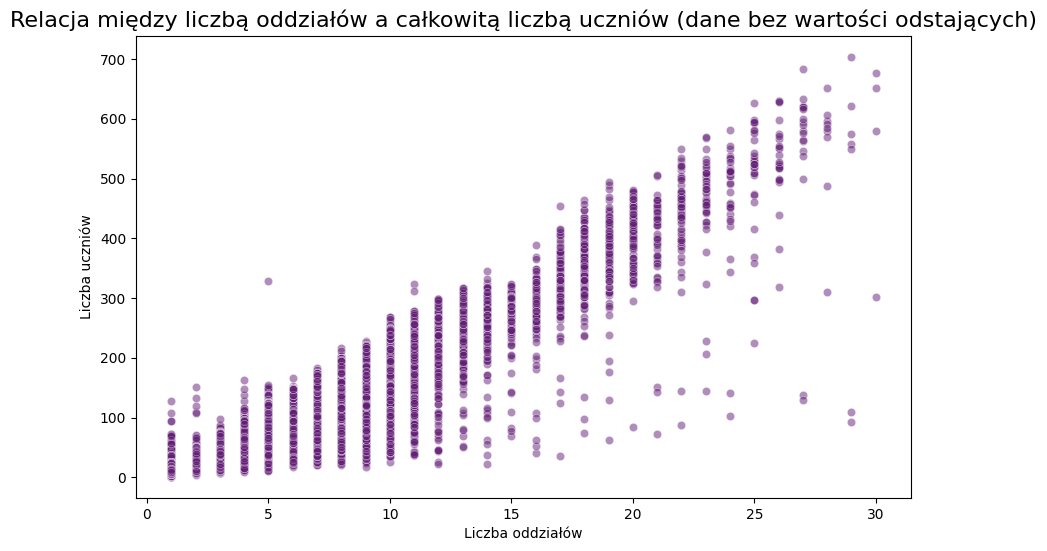

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='lb_oddz', y='ucz_ogolem', data=df_no_outliers, alpha=0.5, color='#631D76')
plt.title('Relacja między liczbą oddziałów a całkowitą liczbą uczniów (dane bez wartości odstających)', fontsize=16)
plt.xlabel('Liczba oddziałów')
plt.ylabel('Liczba uczniów')
plt.show()

Wraz ze wzrostem liczby oddziałów rośnie liczba uczniów, co jest zjawiskiem naturalnym. Widoczne są również skokowe zmiany obu zmiennych a szczególnie zauważalne jest to w przypadku liczby oddziałów.

## 6. Porównanie względem cechy jakościowej

### Statystyki opisowe Liczby uczniów względem Typu Gminy

In [46]:
statystyki_gmina = df_clean.groupby('typ_gminy')['ucz_ogolem'].describe()[['count', 'mean', '50%', 'std']]
statystyki_gmina.columns = ['Liczba placówek', 'Średnia liczba uczniów', 'Mediana liczby uczniów', 'Odch. std.']
display(statystyki_gmina)

,Liczba placówek,Średnia liczba uczniów,Mediana liczby uczniów,Odch. std.
typ_gminy,,,,
Gm,9848.0,132.385357,98.0,129.401110
M,19369.0,202.421860,111.0,246.619115
M-Gm,9751.0,156.648857,100.0,171.627948


In [47]:
statystyki_uczniowie = (df_no_outliers.groupby('typ_gminy')['ucz_ogolem'].agg(['count', 'mean', 'median', 'std']).rename(columns={
        'count': 'Liczba obserwacji',
        'mean': 'Średnia liczba uczniów',
        'median': 'Mediana',
        'std': 'Odch. std.'
    })
)

display(statystyki_uczniowie)

,Liczba obserwacji,Średnia liczba uczniów,Mediana,Odch. std.
typ_gminy,,,,
Gm,4858,122.410457,101.0,93.280864
M,6173,103.106755,88.0,88.970224
M-Gm,3817,121.309667,99.0,101.640284


Porównanano statystki liczby uczniów względem typu gminy, dodatkowo porównano dane z wartościami odstającymi i bez. 

Analiza wskazuje, że przed usunięciem wartości odstających gminy miejskie charakteryzują się najwyższą średnią liczbą uczniów, co wynika z obecności nielicznych, bardzo dużych placówek silnie zawyżających wyniki. Jednocześnie mediana pozostaje znacznie niższa, co sugeruje, że typowa placówka w mieście nie jest największa. 

Po wyeliminowaniu wartości odstających średnia liczba uczniów w gminach miejskich spada poniżej poziomu obserwowanego w gminach wiejskich i miejsko-wiejskich. Wskazuje to, że poza miastami placówki są przeciętnie większe i bardziej jednorodne. Ostatecznie, **wartości odstające mają istotny wpływ** na interpretację danych i mogą prowadzić do mylnych wniosków, jeśli nie zostaną uwzględnione w analizie.

Wnioski:
* Miasta mają największe placówki, ale nie przeciętne - tylko skrajne przypadki zawyżają średnią. Po usunięciu outlierów placówki w miastach są przeciętnie mniejsze, większe są w gminach wiejskich i miejsko-wiejskich
* Mediany są stabilniejsze w obu przypadkach
* Usunięcie outlierów najbardziej wpłynęło na szkoły miejskie
* W miastach występują ekstremalnie duże placówki, które „ciągną” średnią w górę

### Rozkład liczby oddziałów względem publiczności

Text(0.5, 0.98, 'Porównanie rozkładu wielkości placówek (liczba oddziałów poniżej 50)')

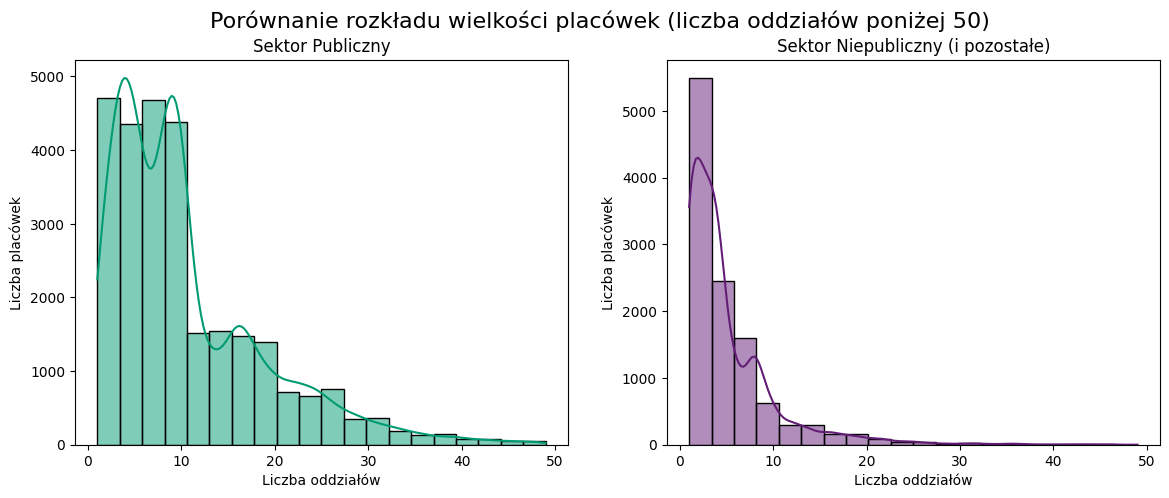

In [48]:
df_plot = df_clean[df_clean['lb_oddz'] < 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Histogram dla sektora publicznego
sns.histplot(df_plot[df_plot['publicznosc'] == 'publiczna']['lb_oddz'], kde=True, color='#009B72', ax=axes[0], bins=20)
axes[0].set_title('Sektor Publiczny')
axes[0].set_xlabel('Liczba oddziałów')
axes[0].set_ylabel('Liczba placówek')

# Histogram dla sektora niepublicznego
sns.histplot(df_plot[df_plot['publicznosc'] != 'publiczna']['lb_oddz'], kde=True, color='#631D76', ax=axes[1], bins=20)
axes[1].set_title('Sektor Niepubliczny (i pozostałe)')
axes[1].set_xlabel('Liczba oddziałów')
axes[1].set_ylabel('Liczba placówek')

plt.suptitle('Porównanie rozkładu wielkości placówek (liczba oddziałów poniżej 50)', fontsize=16)

Zestawienie dwóch histogramów obok siebie pozwala na bezpośrednie porównanie struktury wielkości placówek publicznych i niepublicznych - struktury różnią się. Zastosowano przycięcie danych do maksymalnie 50 oddziałów w celu zwiększenia czytelności. W sektorze publicznym rozkład jest szerszy - występuje duża liczba placówek posiadających do 20 oddziałów. Świadczy to o rozbudowanej, systemowej strukturze tych jednostek. W pozostałych formach rozkład jest dużo bardziej skupiony. Większość posiada mniej niż 10 oddziałów.

### Rozkład liczby oddziałów względem typu placówki

C:\Users\Iza\AppData\Local\Temp\ipykernel_16528\4189052132.py:2: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_clean, x='lb_oddz', y='publicznosc', palette=['#009B72', '#631D76'])


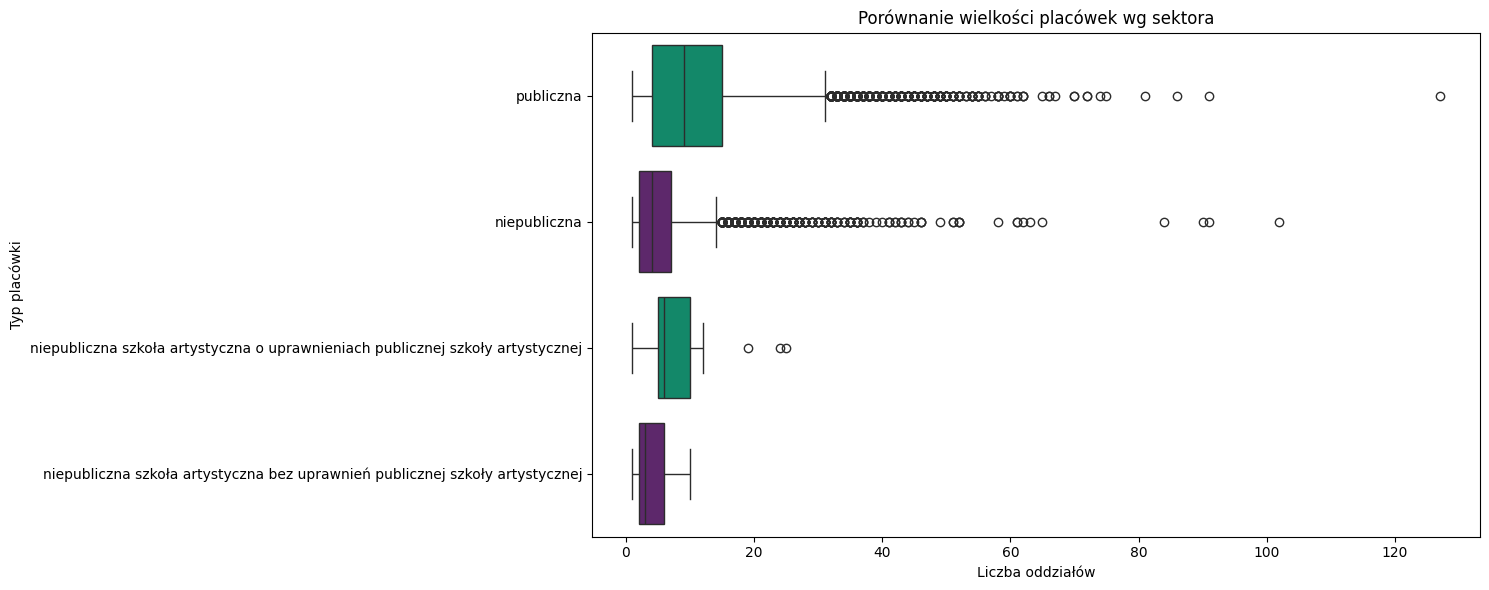

In [49]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_clean, x='lb_oddz', y='publicznosc', palette=['#009B72', '#631D76'])

plt.title('Porównanie wielkości placówek wg sektora')
plt.xlabel('Liczba oddziałów')
plt.ylabel('Typ placówki')
plt.tight_layout()
plt.show()

Sektor Publiczny cechuje się największym rozproszeniem w porównaniu do reszty - mediana również jest najwyższa. Placówki niepubliczne swoimi outlierami nie odbiegają od placówek publicznych, natomiast rozstęp jest dużo mniejszy (pudełko mniej szerokie). Rodzaj organu prowadzącego (publiczny vs niepubliczny) jest silnym determinantem wielkości placówki. W sektorze niepublicznym widać skupienie przy bardzo małych wartościach, co może świadczyć o dużej liczbie małych punktów przedszkolnych lub prywatnych szkół o małej liczebności klas.

### Porównanie kadr według kategorii uczniów

C:\Users\Iza\AppData\Local\Temp\ipykernel_16528\2366731120.py:7: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(x=cat_stats.values, y=cat_stats.index, palette=my_colors)


Text(0, 0.5, 'Kategoria uczniów')

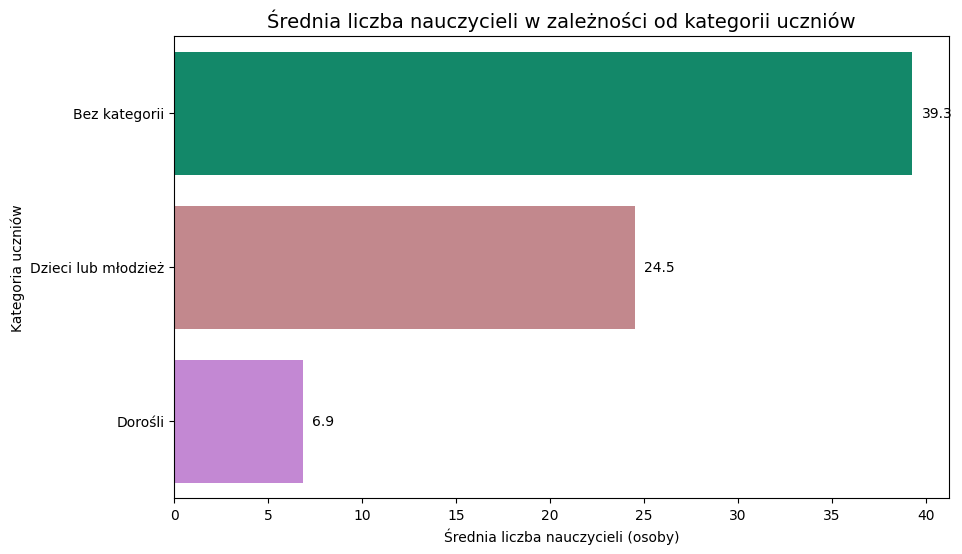

In [50]:
cat_stats = df_clean.groupby('kategoria_uczniow')['lb_naucz_osoby'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

my_colors = ["#009B72", "#CC7E85", "#CA7CDF", "#66C3FF"]

sns.barplot(x=cat_stats.values, y=cat_stats.index, palette=my_colors)

for i, v in enumerate(cat_stats.values):
    plt.text(v + 0.5, i, f'{v:.1f}', va='center')

plt.title('Średnia liczba nauczycieli w zależności od kategorii uczniów', fontsize=14)
plt.xlabel('Średnia liczba nauczycieli (osoby)')
plt.ylabel('Kategoria uczniów')


Przedstawiono średnią liczbę nauczycieli w zależności od grupy docelowej placówki (nazwanej jako kategoria uczniów). 

Wnioski:
* Bez kategorii **(39,3)**: Najliczniejsza kadra. Są to prawdopodobnie duże, wielofunkcyjne zespoły szkół lub jednostki specjalistyczne o złożonej strukturze
* Dzieci lub młodzież **(24,5)**: Standardowa wielkość zespołu pedagogicznego, typowa dla szkół realizujących pełną podstawę programową w trybie dziennym
* Dorośli **(6,9)**: Najmniejsze zespoły. Wynika to ze specyfiki edukacji dorosłych (tryb zaoczny czy też kursowy), która wymaga znacznie mniejszej obsady stałej niż edukacja dzieci

## 7. Analiza zależności między zmiennymi

In [51]:
df_no_outliers.columns

Index(['wojewodztwo', 'powiat', 'gmina', 'typ_gminy', 'miejscowosc',
       'czy_szkola', 'rspo', 'typ_podmiotu', 'rodzaj_szkoly_placowki',
       'nazwa_placowki', 'ulica', 'numer_domu', 'kod_pocztowy', 'poczta',
       'adres_www', 'regon', 'publicznosc', 'kategoria_uczniow',
       'specyfika_szkoly', 'zwiazanie_organizacyjne',
       'typ_organu_prowadzacego', 'typ_org_prow', 'organ_prowadzacy',
       'organ_rejestrujacey_wojewodztwo', 'organ_rejestrujacy_powiat',
       'organ_rejestrujacy_gmina', 'typ_organu_rejestrujacego',
       'organ_rejestrujacy', 'ucz_ogolem', 'w_tym_ucz_dziewczeta',
       'w_tym_w_oddz_przedszk', 'lb_oddz', 'etat_umowa',
       'w_tym_etat_niepelnozatr', 'lb_naucz_osoby', 'w_tym_lb_naucz_pelnozatr',
       'w_tym_lb_naucz_niepelnozatr'],
      dtype='object')

### Pair plot + Heatmap: Analiza współzależności wielowymiarowej

<Figure size 1000x1000 with 0 Axes>

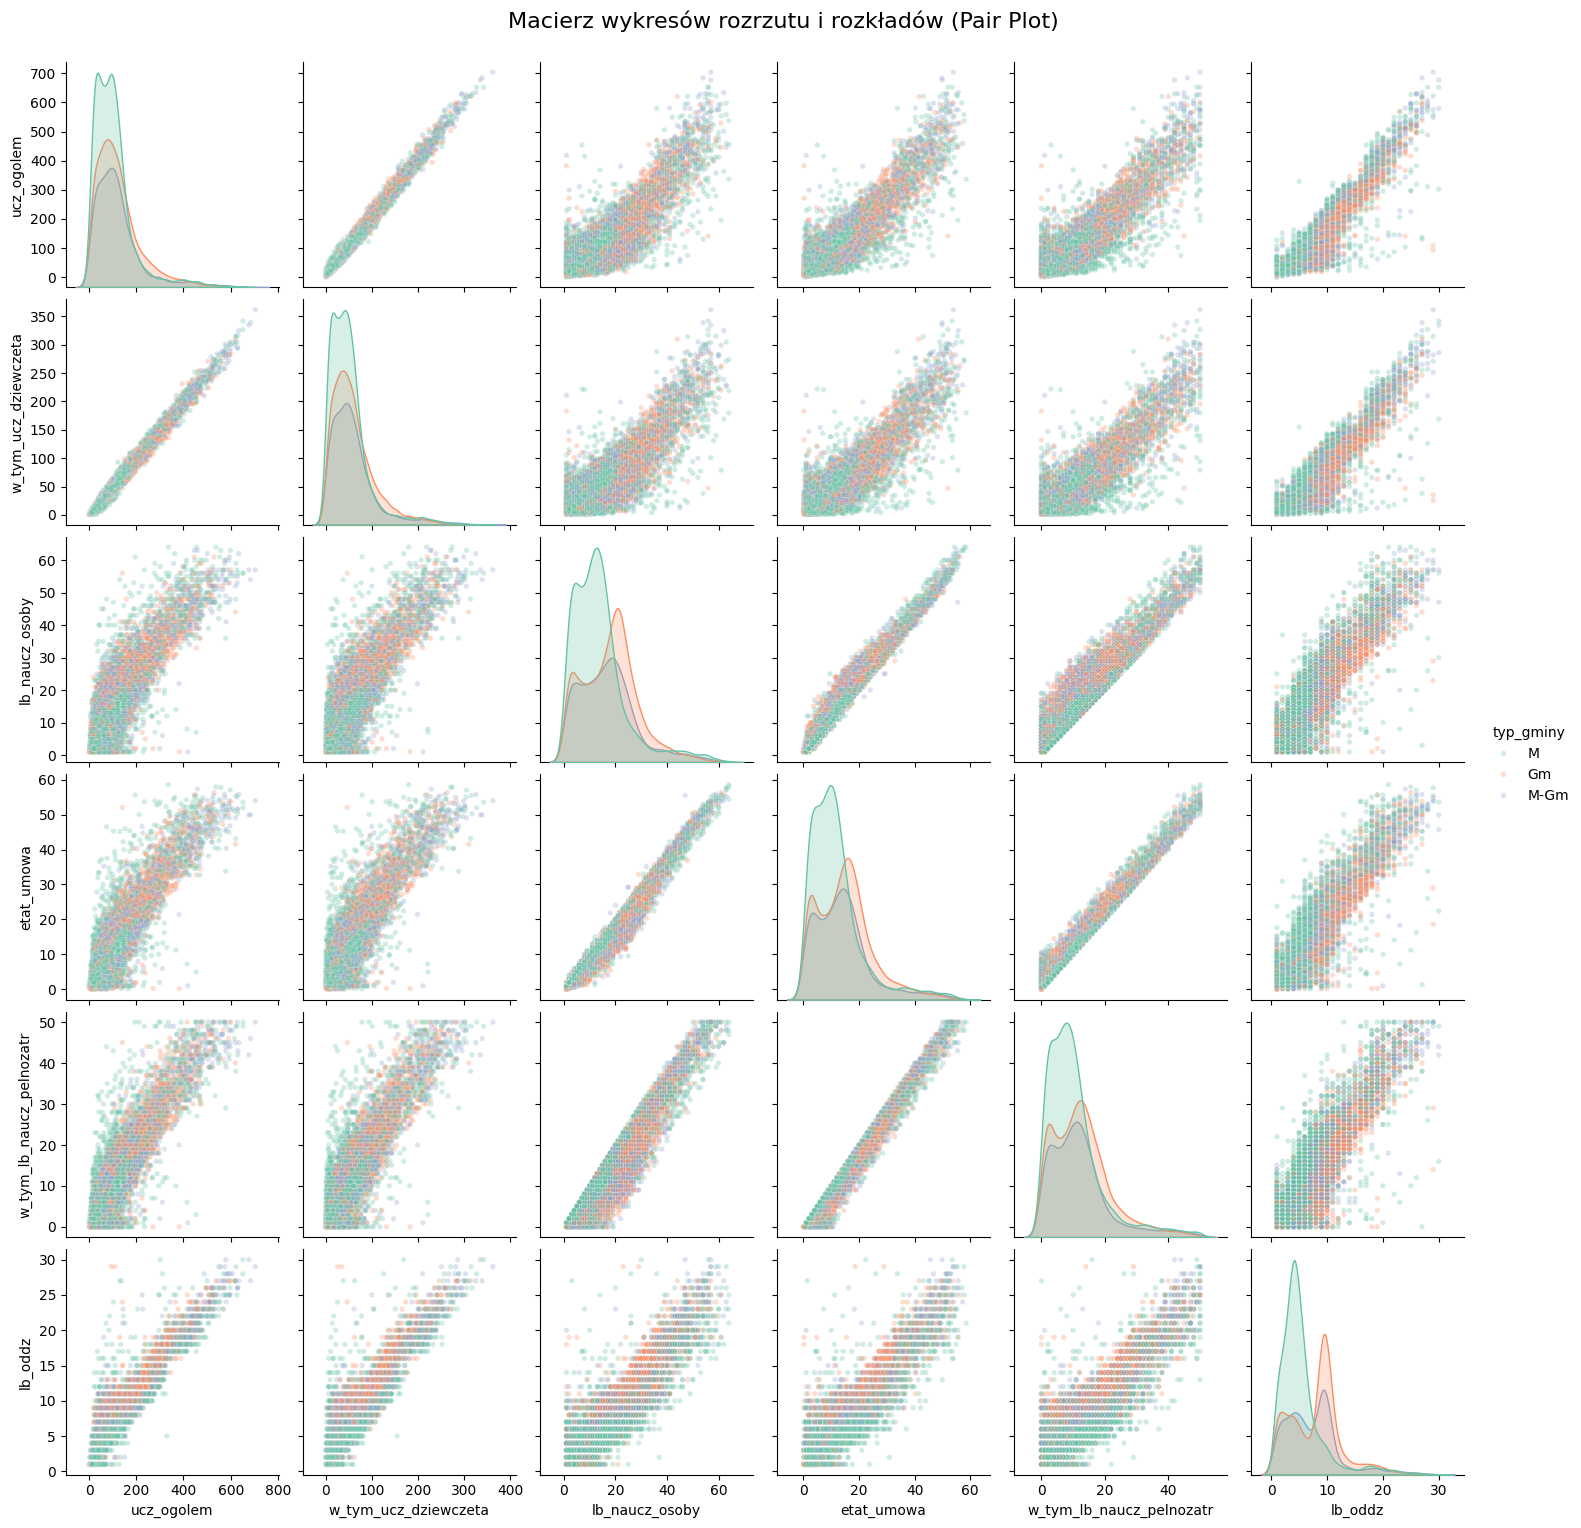

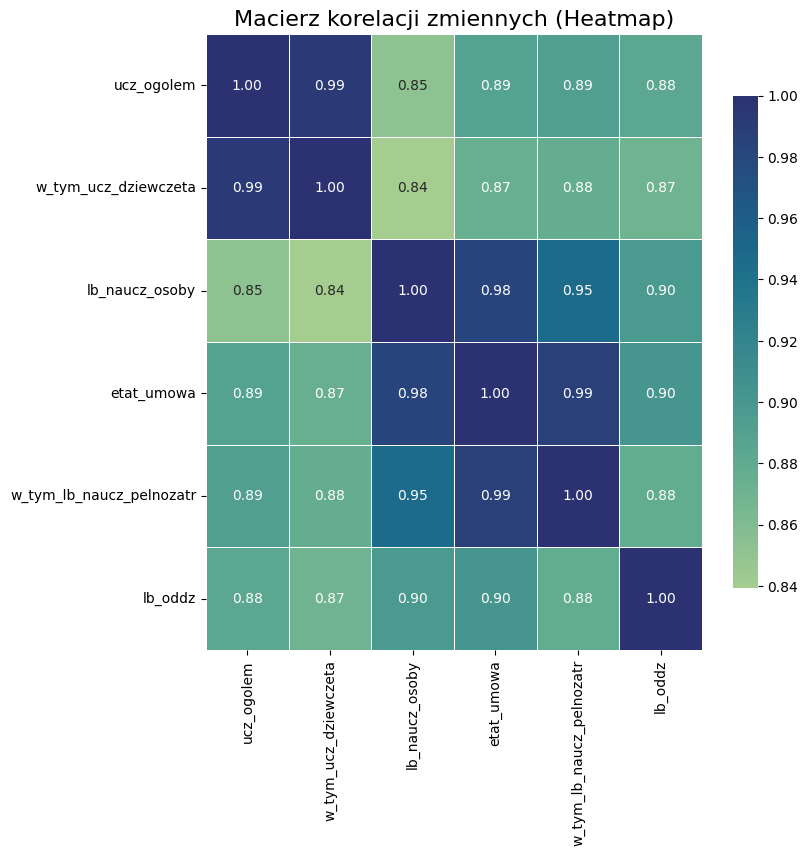

In [52]:
cols = [
    'ucz_ogolem', 
    'w_tym_ucz_dziewczeta', 
    'lb_naucz_osoby', 
    'etat_umowa',
    'w_tym_lb_naucz_pelnozatr',
    'lb_oddz'
]
cols_pairplot = cols + ['typ_gminy']

plt.figure(figsize=(10, 10))
g = sns.pairplot(df_no_outliers[cols_pairplot], hue='typ_gminy', diag_kind='kde', palette='Set2', plot_kws={'alpha':0.3, 's':15})
g.fig.suptitle('Macierz wykresów rozrzutu i rozkładów (Pair Plot)', fontsize=16, y=1.02)

plt.figure(figsize=(8, 8))
corr_matrix = df_no_outliers[cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='crest', linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Macierz korelacji zmiennych (Heatmap)', fontsize=16)
plt.show()

Do analizy zależności między zmiennymi wykorzystano **dane wyczyszczone z wartości odstających**. Zastosowano połączenie macierzy wykresów rozrzutu (Pair Plot) oraz mapy ciepła (heatmap) i pozwoliło to na kompleksową ocenę zależności w zbiorze danych. Dodatkowym elementem analizy było wykorzystanie zmiennej jakościowej **typ_gminy** jako czynnika różnicującego w Pair Plotach.

* Wszystkie zmienne są ze sobą powiązane (im więcej oddziałów, tym więcej uczniów, dziewcząt, nauczycieli i etatów)  - **wartość współczynnika korelacji nie schodzi poniżej 0.84**
* Analiza wizualna wykresów rozrzutu wskazuje, że charakter zależności między zmiennymi ilościowymi jest bardzo zbliżony dla wszystkich typów gmin
* Nachylenie linii trendu na wykresach rozrzutu pozostaje niemal identyczne niezależnie od typu gminy. Świadczy to o tym, że liczba nauczycieli na jednego ucznia jest zbliżona w całym systemie, bez względu na stopień urbanizacji danego obszaru (czyli typ gminy)
* Wykresy na przekątnej ujawniają, że gminy miejskie (często reprezentowane przez szersze rozkłady) są często bardziej zróżnicowane, **ujawniają różnice w skali placówek lepiej niż wykresy rozrzutu**
* W macierzy korelacji świadomie zrezygnowano ze standardowego zakresu skali $[-1, 1]$ na rzecz skali dopasowanej do rzeczywistego zakresu danych ($0.84 - 1.00$). Zabieg ten pozwolił na lepsze wizualne zróżnicowanie bardzo wysokich współczynników, które przy pełnej skali byłyby graficznie nieodróżnialne
* Ekstremalnie silne korelacje: Współczynniki rzędu 0.98 (między liczbą nauczycieli a etatami) oraz 0.99 (między liczbą uczniów a liczbą dziewcząt) wskazują na niemal idealną liniowość zależności

### Regplot: Analiza regresji z i bez uwzględnienia danych odstających

Text(0.5, 0.98, 'Wpływ wartości odstających na analizę regresji')

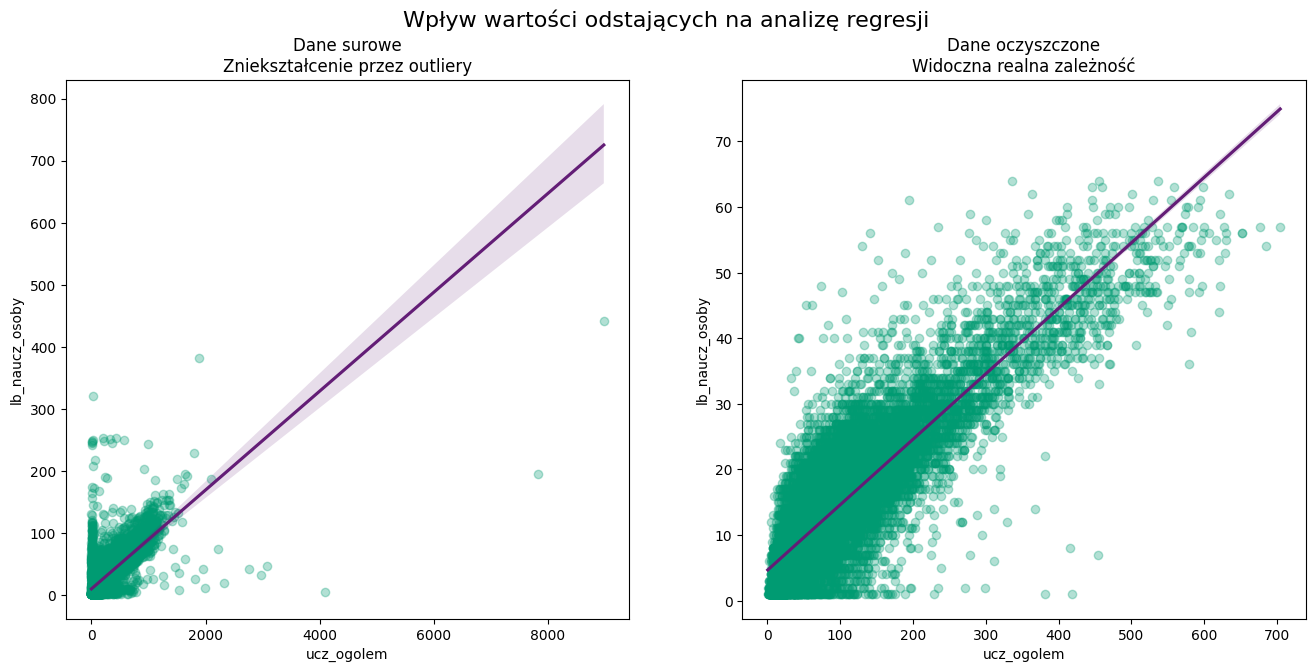

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.regplot(data=df_clean, x='ucz_ogolem', y='lb_naucz_osoby', scatter_kws={'alpha':0.3, 'color':'#009B72'}, line_kws={'color':'#631D76'}, ax=axes[0])
axes[0].set_title('Dane surowe\nZniekształcenie przez outliery', fontsize=12)


sns.regplot(data=df_no_outliers, x='ucz_ogolem', y='lb_naucz_osoby', scatter_kws={'alpha':0.3, 'color':'#009B72'}, line_kws={'color':'#631D76'}, ax=axes[1])
axes[1].set_title('Dane oczyszczone\nWidoczna realna zależność', fontsize=12)

plt.suptitle('Wpływ wartości odstających na analizę regresji', fontsize=16)

W analizie zależności zdecydowano się na porównanie zbioru surowego (**df_clean**) ze zbiorem oczyszczonym z wartości odstających (**df_no_outliers**). Takie podejście zostało zastosowane z następujących powodów:
* Na wykresie dla danych surowych (lewy) widać, że pojedyncze, rekordowo duże placówki (posiadające np. kilka tysięcy uczniów) wymuszają drastyczne rozciągnięcie osi
* Usunięcie outlierów pozwoliło uzyskać model, który lepiej opisuje "typową" zależność między kadrą a liczbą uczniów
* Dopiero na wykresie po prawej stronie widać rzeczywisty rozrzut punktów i to, jak stabilnie rośnie liczba nauczycieli wraz z wielkością szkoły

Czyszczenie danych z wartości odstających nie było próbą ich zatajenia, lecz niezbędnym zabiegiem technicznym, mającym na celu przywrócenie właściwej skali analizy i uniknięcie błędnych wniosków statystycznych opartych na przypadkowych rekordach. Natomiast, jak wcześniej ukazano, ekstremalne wartości np. liczby uczniów ogółem dają bardzo ciekawe wnioski do ogólnej analizy.

## 8. Wnioski końcowe

Przeprowadzona analiza statystyczna danych dotyczących placówek oświatowych w Polsce była bardzo interesującym doświadczeniem, pozwalająca na nieskończoną liczbę wykresów, sprawdzanai zależności i pozwoliła na sformułowanie następujących wniosków:
* **Zróżnicowanie danych:** Dane charakteryzują się bardzo wysoką zmiennością i skośnością prawostronną. Wartości średnie są istotnie wyższe od median, co wynika z asymetrii rozkładów i obecności dużych szkół zbiorczych
* **Obserwacje odstające (Outliery):** W zbiorze zidentyfikowano liczne obserwacje odstające - szkoły-giganty, w których liczba uczniów przekraczała 1000 (max ponad 8000), a kadra liczyła setki osób. Obserwacje te, choć autentyczne, zniekształcały modele statystyczne (np. linię regresji), dlatego do analizy korelacji niezbędne było wykorzystanie zbioru oczyszczonego (df_no_outliers)
* **Zaobserwowane zależności:** Wykazano ekstremalnie silną, dodatnią ko. relację liniową (współczynniki powyżej 0.90) między liczbą uczniów, liczbą oddziałów a wielkością kadry pedagogicznej. Oznacza to, że system oświatowy działa w sposób wysoce przewidywalny, a zapotrzebowanie na kadre rośnie wraz ze wzrostem liczby uczniów
* Badany zbiór danych ukazuje obraz polskiej oświaty jako systemu o bardzo sztywnej strukturze korelacyjnej, ale ogromnym zróżnicowaniu skali. Kluczowym wnioskiem analitycznym jest konieczność oddzielania typowych jednostek od rekordowych outlierów w celu uzyskania rzetelnego obrazu statystycznego
* Warto zaznaczyć, że analizowany zbiór danych, mimo swojej złożoności i licznych wyzwań technicznych (takich jak konieczność radzenia sobie z ekstremalnymi wartościami odstającymi), stanowi niezwykle ciekawy materiał badawczy. Dane te mają charakter rzeczywisty, co sprawia, że analiza nie jest jedynie ćwiczeniem teoretycznym, lecz próbą opisu żywego, zróżnicowanego systemu społecznego. Proces „czyszczenia” danych i odkrywania silnych, matematycznych wręcz zależności pod warstwą pozornego chaosu, był najbardziej wartościowym etapem pracy, pozwalającym zrozumieć mechanizmy rządzące współczesną strukturą oświaty.